<a href="https://colab.research.google.com/github/Nikitoniy/Yandex_Data_Analysis/blob/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%BE%D1%82%D1%82%D0%BE%D0%BA%D0%B0_%D0%BA%D0%BB%D0%B8%D0%B5%D0%BD%D1%82%D0%BE%D0%B2_%D0%B1%D0%B0%D0%BD%D0%BA%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Материалы:

- Презентация: <https://drive.google.com/file/d/1cHyWbctGBbAZ6hYm-GzAUi4KrhxAeiTj/view?usp=sharing>

# Анализ оттока клиентов банка

**Описание проекта:** главными задачами станут анализ оттока клиентов и сегментирование пользователей банка. Сегментация в свою очередь покажет, как клиенты пользуются нашими услугами.

**Цель проекта:** в ходе исследования необходимо проверить вводные данные, и предобработать их. Необходимо рассмотреть распределения ключевых значений, а также необходимо сосавить описания типичных пользователей и выделить в них доли отточных клиентов.

**Описание изначального датасета:** всего представлена одна таблица:
- `userid` - идентификатор пользователя;
- `score` - баллы кредитного скоринга;
- `gender` - пол;
- `city` - город;
- `age` - возраст;
- `equity` - приблизительная оценка собственности клиента;
- `balance` - баланс на счёте;
- `products` - количество продуктов, которыми пользуется клиент;
- `credit_card` - есть ли кредитная карта;
- `last activity` - был ли клиент активен последнее время;
- `est_salary` - оценочная заработная плата клиента;
- `churn` - уходит или нет.

## Изучение общей информации

### Импорт библиотек

In [1]:
pip install phik

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
from phik import phik_matrix
from scipy import stats as st

warnings.simplefilter('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

### Изучение датасета

In [3]:
data = pd.read_csv('https://code.s3.yandex.net/datasets/bank_scrooge.csv')

display(data.head())
display(data.info())

,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
0,183012,850.00,Рыбинск,Ж,25.00,1,59214.82,2,0,1,75719.14,1
1,146556,861.00,Рыбинск,Ж,37.00,5,850594.33,3,1,0,86621.77,0
2,120722,892.00,Рыбинск,Ж,30.00,0,NaN,1,1,1,107683.34,0
3,225363,866.00,Ярославль,Ж,51.00,5,1524746.26,2,0,1,174423.53,1
4,157978,730.00,Ярославль,М,34.00,5,174.00,1,1,0,67353.16,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   USERID         10000 non-null  int64  
 1   score          10000 non-null  float64
 2   city           10000 non-null  object 
 3   gender         10000 non-null  object 
 4   age            9974 non-null   float64
 5   equity         10000 non-null  int64  
 6   balance        7705 non-null   float64
 7   products       10000 non-null  int64  
 8   credit_card    10000 non-null  int64  
 9   last_activity  10000 non-null  int64  
 10  EST_SALARY     10000 non-null  float64
 11  churn          10000 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 937.6+ KB


None

**Промежуточный итог:** в таблице обнаружены замечания:
- Пропуски по столбцам `age` и `balance`;
- Неправильно определены типы данных в колонках `score` и `age`.

## Подготовка данных

### Изменение регистра у колонок и строк

In [4]:
data.columns = data.columns.str.lower()

def clean_strings(df):
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].str.strip().str.lower()
    return df

data = clean_strings(data)

data.head()

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
0,183012,850.00,рыбинск,ж,25.00,1,59214.82,2,0,1,75719.14,1
1,146556,861.00,рыбинск,ж,37.00,5,850594.33,3,1,0,86621.77,0
2,120722,892.00,рыбинск,ж,30.00,0,NaN,1,1,1,107683.34,0
3,225363,866.00,ярославль,ж,51.00,5,1524746.26,2,0,1,174423.53,1
4,157978,730.00,ярославль,м,34.00,5,174.00,1,1,0,67353.16,1


**Промежуточный итог:** были изменены регистр колонок и строк на общий - нижний - для более удобных манипуляций с данными, а также для избежания дополнительных рисков дубликатов.

### Добавление новых колонок

In [5]:
#если есть пустое значение то 1 иначе 0
data['have_null'] = data.isna().any(axis=1).astype(int)

#копии столбцов чтобы не потерять оригинальный столбец

data['city_copy'] = data['city']
data['gender_copy'] = data['gender']

#кодировка столбцов
data = pd.get_dummies(data, columns = ['city_copy', 'gender_copy'], dtype=int)

data = data.rename(columns = ({
                                'city_copy_ростов':'ростов',
                                'city_copy_рыбинск':'рыбинск',
                                'city_copy_ярославль':'ярославль',
                                'gender_copy_ж':'female',
                                'gender_copy_м':'male'
                              }))

data.head()

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,have_null,ростов,рыбинск,ярославль,female,male
0,183012,850.00,рыбинск,ж,25.00,1,59214.82,2,0,1,75719.14,1,0,0,1,0,1,0
1,146556,861.00,рыбинск,ж,37.00,5,850594.33,3,1,0,86621.77,0,0,0,1,0,1,0
2,120722,892.00,рыбинск,ж,30.00,0,NaN,1,1,1,107683.34,0,1,0,1,0,1,0
3,225363,866.00,ярославль,ж,51.00,5,1524746.26,2,0,1,174423.53,1,0,0,0,1,1,0
4,157978,730.00,ярославль,м,34.00,5,174.00,1,1,0,67353.16,1,0,0,0,1,0,1


**Промежуточный итог:** добавлены новые колонки в таблицу:
- Колонка с признаком города Ростов;
- Колонка с признаком города Рыбинск;
- Колонка с признаком города Ярославль;
- Колонка с признаком мужского пола;
- Колонка с признаком женского пола;
- Колонка с признаком присутствия пустых значений;

### Предобработка пропусков

#### Общая оценка пропусков в таблице

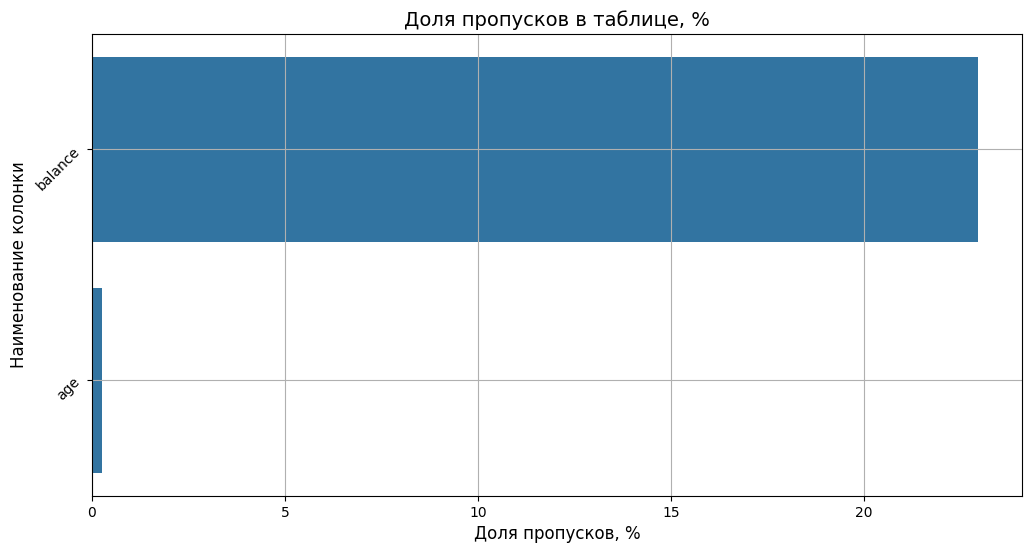

In [6]:
#функция для подсчета пустых значений и график по таким значениям
def ratio_null(df):
#пустой список, который буду далее использовать
    new_list = []

    #для каждой колонки считаю долю пропусков и добавляю в список
    for column in df.columns:
        ratio_perc = round(((df[column].isnull().sum() / len(df)) * 100), 2)
        new_list.append((column, ratio_perc))

    #создание таблицы, убираю значения меньше нуля, сортировка
    new_df = pd.DataFrame(new_list, columns=['name_column', 'ratio_null'])
    new_df = new_df.query('ratio_null > 0').sort_values('ratio_null', ascending=False)

    #настройка графика
    plt.figure(figsize=(12, 6))
    sns.barplot(y=new_df['name_column'], x=new_df['ratio_null'], data=new_df)

    plt.xlabel('Доля пропусков, %', fontsize=12)
    plt.ylabel('Наименование колонки', fontsize=12)
    plt.title('Доля пропусков в таблице, %', fontsize=14)
    plt.yticks(rotation=45)
    plt.grid(visible=True)
    plt.show()

ratio_null(data)

**Промежуточный итог:** по колонке `age` минимальное количество пропусков, а по колонке `balance` - более 20% пропусков.

Рассмотрим пропуски подробнее.

#### Корреляционный анализ пропусков

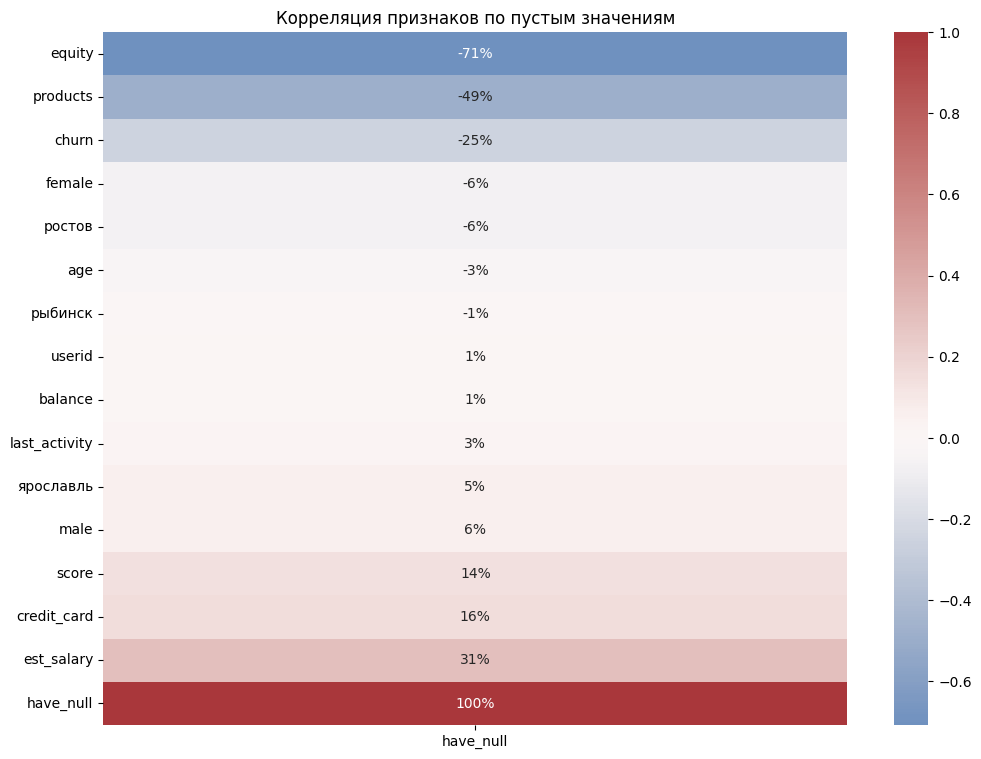

'Доля пользователей с оценкой собственности 0 и пустыми значениями от всех пустых значений: 94.58%'

In [7]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    data.drop(columns=['city', 'gender']).corr().loc[:,['have_null']]
    .sort_values('have_null'), annot=True, fmt=".0%", cmap="vlag", center=0)

plt.title('Корреляция признаков по пустым значениям')

plt.show()

display('Доля пользователей с оценкой собственности 0 и пустыми значениями от всех пустых значений: {}%'
        .format(
            round(
                data
                .query('equity == 0 and have_null == 1')['userid'].count() /
                data.query('have_null == 1')['userid'].count() * 100,
                2
            )
        )
       )

**Промежуточный итог:** интересно, что по некоторым признакам пустые значения коррелируют, например, по оценке собственности наибольшая корреляция и она имеет средний уровень корреляции.

Стоит отметить, что 95% от всех пропусков в таблице занимают пропуски, из-за оценки собственности 0.

Думаю, пропуски по колонке `age` - можно причислить к категории **MAR (Missing At Random / Отсутствует случайно)** — в рамках каждой из групп, которая есть в описываемой данными совокупности, распределение пропусков случайно, можно их отбрасывать.

В свою очередь пропуски по `balance` - **MNAR (Missing Not At Random / Отсутствует не случайно)** — пропуски зависят от данных, без дополнительного обоснования их нельзя отбрасывать или заполнять одним значением, т.к. это приведёт к заметным искажениям.

#### Удаление пропусков и других значений

In [8]:
data = data.dropna(subset=['age'])

data = data.query('products > 0')

**Промежуточный итог:**

Пропусков по колонке `balance` - более 20% от всей таблицы, а 95% от всех пропусков в таблице занимают пропуски, из-за оценки собственности 0. Поэтому принято решение такие значения оставить, а сами пропуски по колонке `balance` отнести к категории **MNAR**

Пропуски по колонке `age` - минимальное количество пропусков (менее 1%), сложно сказать, откуда они появились, но, скорее всего, не имеют какой-либо зависимости от других данных. Такие пропуски отмечены как **MAR**.

Дополнительно на предыдущем этапе замечено миниммальное количество продуктов у клиента - 0. Такая строчка всего одна, поэтому была удалена.

### Изменение типов данных

In [9]:
data['score'] = pd.to_numeric(data['score'], downcast="integer")
data['age'] = pd.to_numeric(data['age'], downcast="integer")
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9973 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   userid         9973 non-null   int64  
 1   score          9973 non-null   int16  
 2   city           9973 non-null   object 
 3   gender         9973 non-null   object 
 4   age            9973 non-null   int8   
 5   equity         9973 non-null   int64  
 6   balance        7695 non-null   float64
 7   products       9973 non-null   int64  
 8   credit_card    9973 non-null   int64  
 9   last_activity  9973 non-null   int64  
 10  est_salary     9973 non-null   float64
 11  churn          9973 non-null   int64  
 12  have_null      9973 non-null   int64  
 13  ростов         9973 non-null   int64  
 14  рыбинск        9973 non-null   int64  
 15  ярославль      9973 non-null   int64  
 16  female         9973 non-null   int64  
 17  male           9973 non-null   int64  
dtypes: float64(2)

**Промежуточный итог:** изменены типы даннных в колонках `age` и `score`. Типы данных изменены на `int`.

### Поиск дубликатов

#### Явные дубликаты

In [10]:
display('Явных дубликатов: {}%'.format((data.duplicated().sum() / len(data))))

'Явных дубликатов: 0.0%'

#### Дубликаты в отдельных колонах

In [11]:
display('--- Уникальные значения колонки city ---')
display(data['city'].unique())
print("\n")
display('--- Уникальные значения gender ---')
display(data['gender'].unique())

'--- Уникальные значения колонки city ---'

array(['рыбинск', 'ярославль', 'ростов'], dtype=object)

'--- Уникальные значения gender ---'

array(['ж', 'м'], dtype=object)

Дубликатов в отдельных колонках по категориальным данным не обнаружено.

Также стоит отдельно рассмотреть дубликаты по колонке `userid`.

In [12]:
data[data.duplicated(subset = ['userid'], keep=False)].sort_values('userid', ascending=False).head(20)

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,have_null,ростов,рыбинск,ярославль,female,male
8497,227795,839,ярославль,м,34,2,326593.14,2,1,0,103314.92,0,0,0,0,1,0,1
8205,227795,840,рыбинск,м,34,2,350768.03,1,1,0,102036.14,1,0,0,1,0,0,1
4216,226719,903,рыбинск,ж,63,0,NaN,1,1,0,138582.58,0,1,0,1,0,1,0
2597,226719,990,ярославль,м,37,4,14648692.14,2,0,0,934412.61,1,0,0,0,1,0,1
2302,220816,934,рыбинск,ж,74,5,1294285.39,3,1,0,95606.80,0,0,0,1,0,1,0
1740,220816,840,ярославль,ж,41,3,1193287.13,2,1,1,76434.94,1,0,0,0,1,1,0
9406,217826,790,рыбинск,ж,46,4,430414.80,2,1,1,49400.37,0,0,0,1,0,1,0
4623,217826,842,ярославль,м,39,4,439747.65,2,0,1,116736.75,1,0,0,0,1,0,1
1970,217643,845,ярославль,м,29,5,733098.45,4,1,1,41443.01,1,0,0,0,1,0,1
4186,217643,804,рыбинск,ж,40,2,301836.65,2,1,1,81137.22,0,0,0,1,0,1,0


**Промежуточный итог:** в датасете отсутсвуют явные дубликаты, а также дубликаты в категориальных данных.

Дополнительно стоит отметить неявные дубликаты - дубликаты в колонке `userid` - такие дубликаты присутствуют, не занимая более 1% от всей таблицы.

**Из интересного:** в целом такие дубликаты представляют только два города: Рыбинск и Ярославль, по другим значениям такие дубликаты различаются, поэтому можно предположить, что данные дубликаты связаны с какой-либо итехнической ошибкой банка или переносом клиентов из одной базы в другую, так как Рыбинск находится недалеко от Ярославля, а именно в его области.

Поэтому принято решение данные дубликаты по `userid` оставить в таблице.

### Поиск аномальных значений

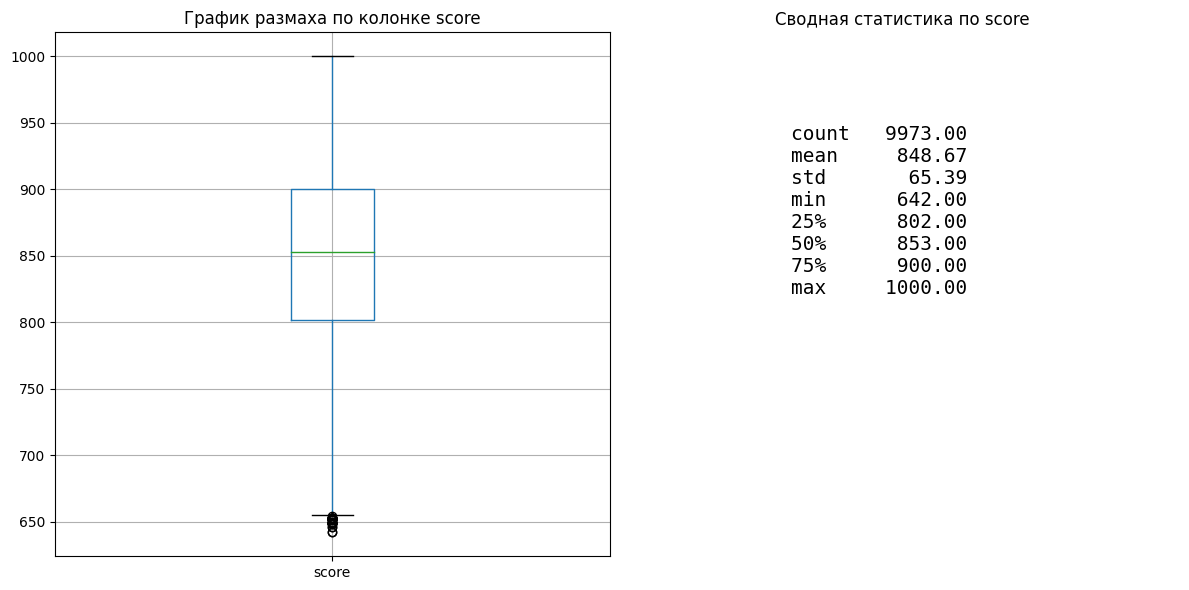

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,have_null,ростов,рыбинск,ярославль,female,male
265,157448,649,рыбинск,м,37,0,NaN,1,1,1,81942.85,0,1,0,1,0,0,1
533,146648,649,ярославль,м,33,0,NaN,1,1,1,149318.49,0,1,0,0,1,0,1
921,179302,646,ярославль,м,37,0,NaN,1,1,1,148297.71,0,1,0,0,1,0,1
2532,151179,642,рыбинск,м,69,0,NaN,1,1,1,35917.41,0,1,0,1,0,0,1
3168,173067,649,ярославль,м,46,0,NaN,1,1,1,121654.31,0,1,0,0,1,0,1
4071,164000,648,ярославль,м,28,0,NaN,1,1,0,27790.15,0,1,0,0,1,0,1
4690,135725,648,ярославль,ж,59,0,NaN,1,1,1,50326.03,0,1,0,0,1,1,0
5131,213745,646,рыбинск,ж,25,0,NaN,2,1,0,60562.33,0,1,0,1,0,1,0
6454,169067,649,ярославль,м,55,0,NaN,1,1,1,130672.40,0,1,0,0,1,0,1
6751,182172,649,ярославль,м,38,0,NaN,1,1,1,170288.90,0,1,0,0,1,0,1


In [13]:
#функция для построения графика и сводной статиски вместе
def quantitative_calc(df, qua_col):
    #создаю переменную для отображения графиков в одной строке
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    #создаю таблицу с грейдом и формирую первый график
    df.boxplot(column=[qua_col], ax=ax1)
    ax1.set_title(f'График размаха по колонке {qua_col}')

    #создаю статистику и формирую второй "график"
    description = df[qua_col].describe()
    ax2.text(0.3, 0.5, description.to_string(), fontfamily='monospace', fontsize=14, transform=ax2.transAxes)
    ax2.axis('off')
    ax2.set_title(f'Сводная статистика по {qua_col}')

    #использую компановку для исключения наложения графиков друг на друга
    plt.tight_layout()
    plt.show()
    print("\n")

quantitative_calc(data, 'score')

data.query('score < 650').head(20)

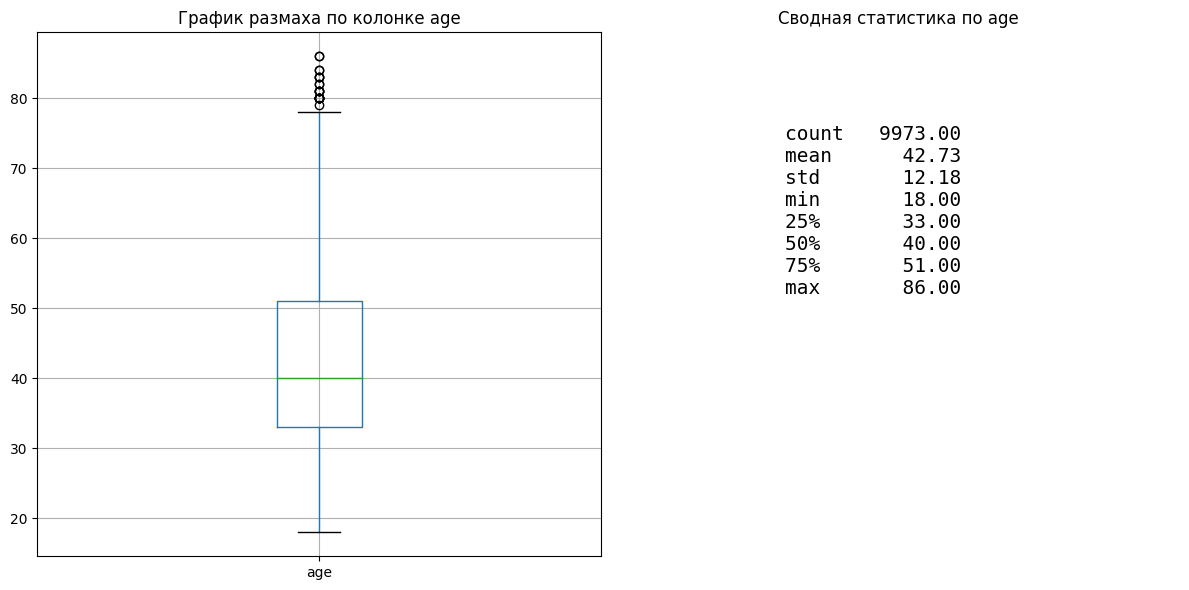

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,have_null,ростов,рыбинск,ярославль,female,male
219,161758,754,ярославль,ж,80,1,332616.82,3,0,1,114804.27,0,0,0,0,1,1,0
396,205650,869,ростов,ж,80,4,570064.04,2,0,0,25503.20,0,0,1,0,0,1,0
540,188460,720,ярославль,ж,80,0,NaN,1,1,1,153804.84,0,1,0,0,1,1,0
1283,127231,796,рыбинск,ж,80,1,347590.32,2,1,0,27123.50,0,0,0,1,0,1,0
1621,151166,916,рыбинск,ж,83,0,NaN,1,1,1,55681.82,0,1,0,1,0,1,0
1987,219132,827,рыбинск,ж,82,3,275391.31,2,0,0,59205.90,0,0,0,1,0,1,0
2063,115610,823,ярославль,ж,81,2,139576.56,2,0,1,146201.01,0,0,0,0,1,1,0
2795,214518,820,ярославль,ж,83,3,1137456.03,3,0,0,18037.97,0,0,0,0,1,1,0
3272,207759,888,ярославль,ж,84,3,1287558.90,2,0,1,97982.17,0,0,0,0,1,1,0
4387,117913,658,рыбинск,ж,81,0,NaN,1,1,1,105088.10,0,1,0,1,0,1,0


In [14]:
quantitative_calc(data, 'age')

data.query('age > 79').head(20)

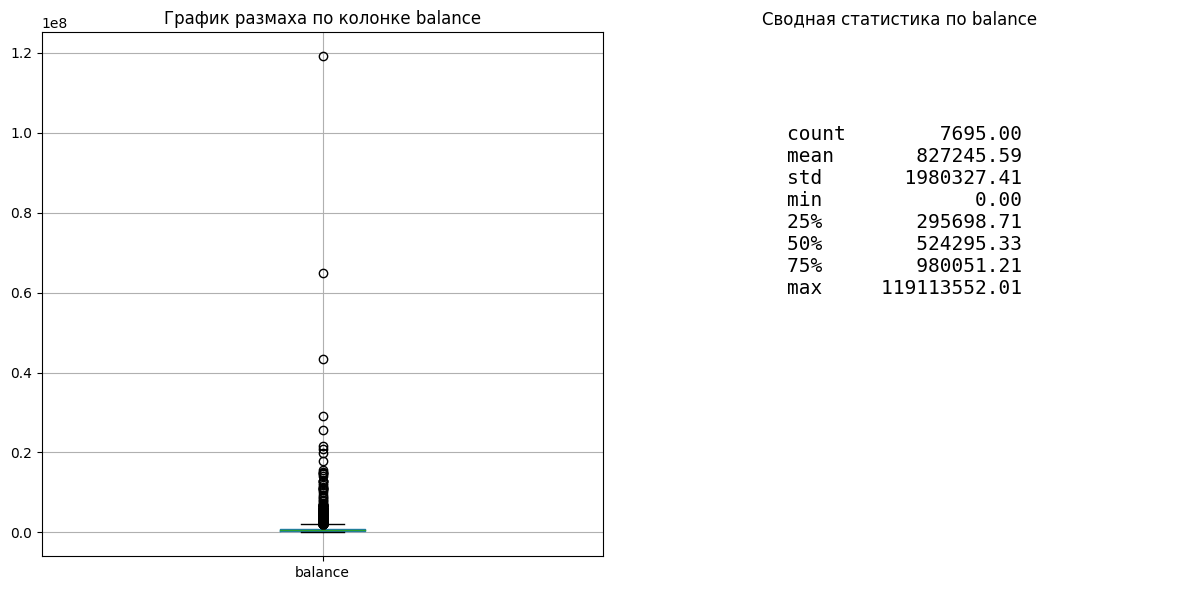

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,have_null,ростов,рыбинск,ярославль,female,male
18,136651,876,ярославль,м,40,5,2307947.36,2,0,0,287010.61,0,0,0,0,1,0,1
44,210313,935,ярославль,м,41,5,3781118.22,2,1,0,761349.20,0,0,0,0,1,0,1
63,140749,948,ярославль,ж,34,5,3134788.66,2,0,0,199705.32,0,0,0,0,1,1,0
74,222208,950,рыбинск,ж,43,4,2332677.14,2,1,1,301845.59,0,0,0,1,0,1,0
77,191976,937,ярославль,м,33,5,2061152.96,2,1,1,280670.62,1,0,0,0,1,0,1
107,134358,985,рыбинск,ж,41,4,6749773.07,2,1,0,698013.27,0,0,0,1,0,1,0
108,227031,870,ярославль,м,39,2,2166303.80,2,1,0,198711.08,0,0,0,0,1,0,1
125,227092,1000,ярославль,м,32,5,19757180.85,2,1,1,1024626.50,0,0,0,0,1,0,1
142,169489,927,рыбинск,м,33,4,2613802.73,2,1,1,132829.92,1,0,0,1,0,0,1
143,198181,958,ярославль,м,34,3,5763239.76,2,1,1,920730.06,1,0,0,0,1,0,1


In [15]:
quantitative_calc(data, 'balance')

data.query('balance > 2000000').head(20)

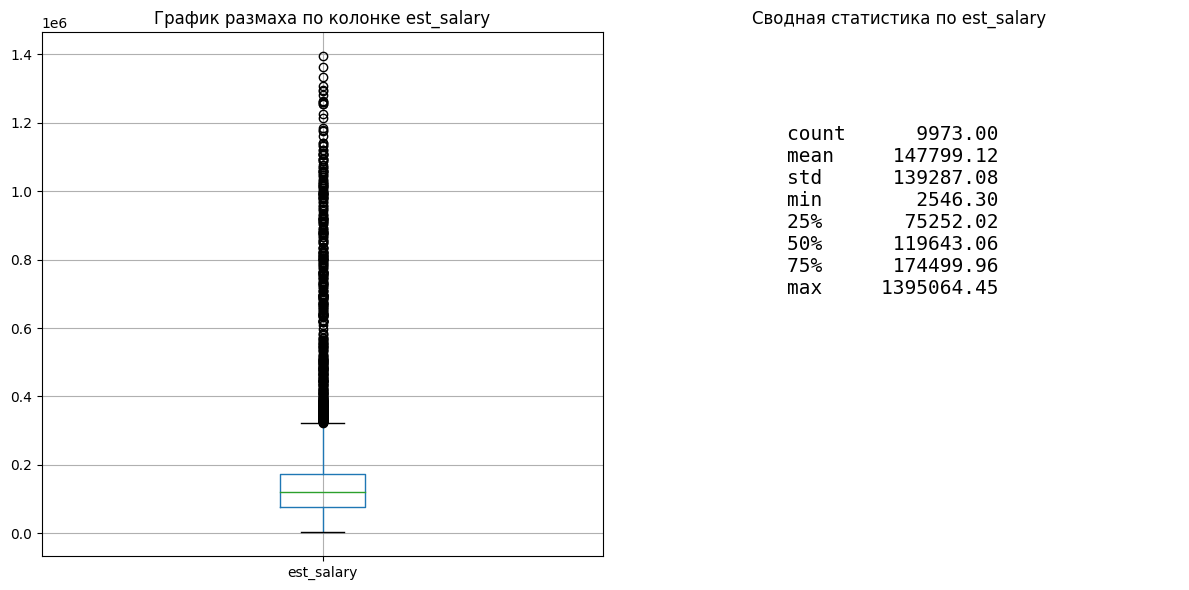

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,have_null,ростов,рыбинск,ярославль,female,male
30,155730,946,ярославль,ж,47,0,NaN,2,1,1,660015.85,0,1,0,0,1,1,0
44,210313,935,ярославль,м,41,5,3781118.22,2,1,0,761349.20,0,0,0,0,1,0,1
107,134358,985,рыбинск,ж,41,4,6749773.07,2,1,0,698013.27,0,0,0,1,0,1,0
124,192966,686,рыбинск,ж,33,0,NaN,1,1,1,518488.59,0,1,0,1,0,1,0
125,227092,1000,ярославль,м,32,5,19757180.85,2,1,1,1024626.50,0,0,0,0,1,0,1
137,163907,761,ярославль,м,31,0,NaN,1,1,0,999177.17,0,1,0,0,1,0,1
138,173386,915,ярославль,ж,48,0,NaN,2,0,0,800733.72,0,1,0,0,1,1,0
139,195558,927,ярославль,м,32,0,NaN,1,1,1,469062.08,0,1,0,0,1,0,1
143,198181,958,ярославль,м,34,3,5763239.76,2,1,1,920730.06,1,0,0,0,1,0,1
149,218801,958,ярославль,м,34,0,NaN,1,1,0,1292825.74,0,1,0,0,1,0,1


In [16]:
quantitative_calc(data, 'est_salary')

data.query('est_salary > 400000').head(20)

Итак, были построенны диаграммы размаха и проанализированы возможные аномалии в таблицы, рассмотрим все колонки:
- `score`: менее 650 баллов;
- `age`: более 79 лет;
- `balance`: более 2 млн. руб.;
- `est_salary`: более 400 тыс. рублей.

Стоит отметить, что данные в датасете актуальные - это говорит о том, что в таблице находятся действительные данные по настоящим клиентам, поэтому аномальные данные убирать не стоит.

При этом и нельзя забывать об аномальных значениях.

### Итог по предобработке

**Отметим важные и интересные моменты:**
- Все колонки и строковые значения приведены к нижнему регистру;
- Добавлены новые колонки по каждому из признаков: есть пустые значения, город Ярославль, город Рыбинск, город Ростов, пол мужской, пол женский;
- Удаление пропусков:
    - Колонка `age`: путсые значения были удалены. Такие значения относятся к MAR и не несут ценной информации. Удаленные данные не заняли более 1% от всей таблицы;
    - Колонка `balance`: принято решение оставить пустые значения. Данные пропуски относятся к MNAR и отсуствуют, в частности, из-за нулевых оценок собственности клиента;
- Явные дубликаты и дубликаты по отдельным колонкам отсутствуют, за исключением колонки `userid`. В таких дубликатах фигурируют города Рыбинск и Ярославь. Возможно, такие значения связаны с возможными ошибками при подготовке данных, поэтому такие значения оставим;
- Поиск аномалий. Следующие аномалии были найдены и будут приняты во внимание в последующем анализе:
    - `score`: менее 650 баллов;
    - `age`: более 79 лет;
    - `balance`: более 2 млн. руб.;
    - `est_salary`: более 400 тыс. рублей.

## Исследовательский анализ данных

### Анализ типичных клиентов

#### Распределение категориальным признакам

In [17]:
def pie_plot(df, attribute):

    #формирую таблицу
    data_for_pie = (
                    df
                    .groupby(attribute, as_index=False)
                    .agg({'userid': 'count'})
                    )

    data_for_pie.columns = ['Признак', 'Количество клиентов']

    #проверка на два значения: 0 и 1
    unique_values = df[attribute].unique()
    if set(unique_values) == {0, 1}:
        mapping = {0: 'Нет', 1: 'Да'}
        data_for_pie['Признак'] = data_for_pie['Признак'].map(mapping)

    #строю график
    data_pie = px.pie(data_for_pie, names='Признак', values='Количество клиентов', color='Признак')

    data_pie.update_layout(
        title=f'Доля всех клиентов банка по {attribute}',
        legend_title=f'Ключевой признак {attribute}'
        )

    data_pie.show()


pie_plot(data, 'gender')

**Промежуточный итог:** интересное распределение клиентов! Первую половину клиентов в базе представляют женщины, вторую - мужчины.

Далее рассмотрим распределение по городу.

In [18]:
pie_plot(data, 'city')

**Промежуточный итог:** более половины клиентов (59%) из Ярославля, четверь клиентов (27%) из Рыбинска, а остальные 14% из Ростова.

In [19]:
pie_plot(data, 'equity')

**Промежуточный итог:** Четверть (26%) пользователей имеют оценку собственности 0. По 19% клиентов с оценкой 5 и 4.

In [20]:
pie_plot(data, 'products')

**Промежуточный итог:** в основнов у клиентов два продукта от банка - 52% таких клиентов. У трети клиентов только один продукт от банка, а 10% имеют три продукта от банка.

In [21]:
pie_plot(data, 'credit_card')

**Промежуточный итог:** 68% клиентов имеют кредитные карты, а те, у кого данных карт нет, 32%.

In [22]:
pie_plot(data, 'last_activity')

**Промежуточный итог:** по последней активности распределение ближе к равному: так активных клиентов в последнее время 52%, а неактивных 48%.

#### Распределение по количественным признакам

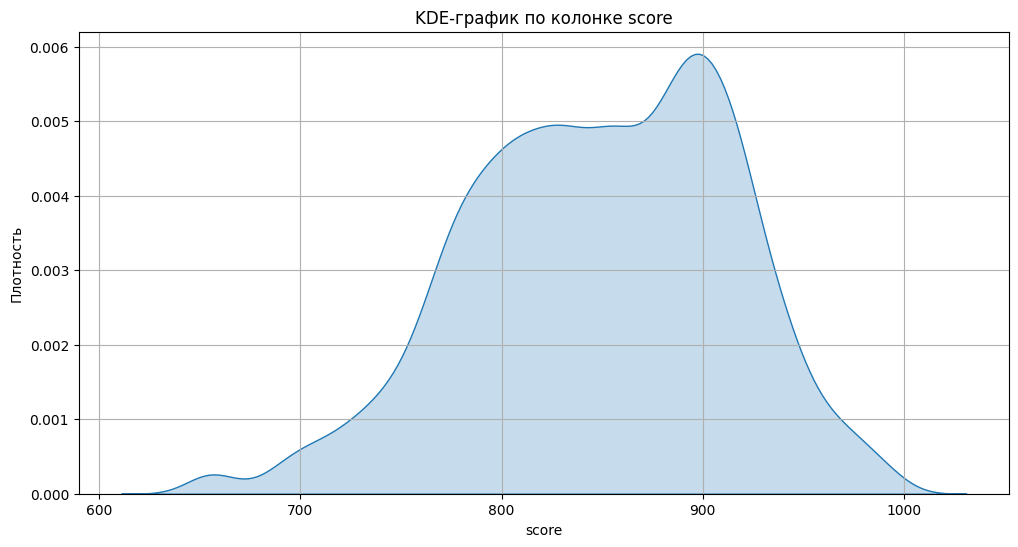

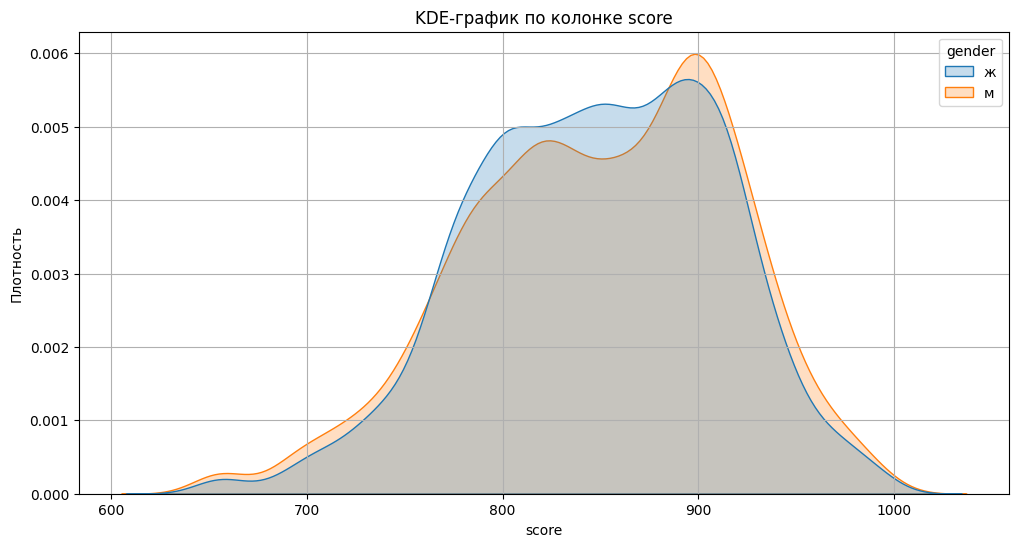

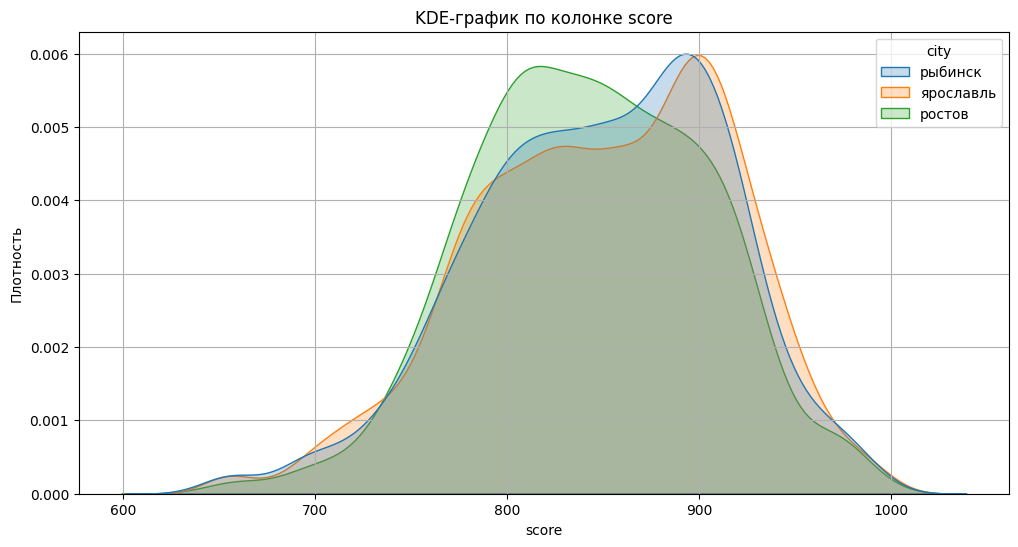

'Доля пользователей с кредитным рейтингом 800 - 900: 51.8%'

In [23]:
def kde_plot(df, kde_col, hue_col=None):
    plt.figure(figsize=(12, 6))

    #если буду смотреть в рарзезе чего-либо
    if hue_col:
        #проверка на два значения: 0 и 1
        unique_values = df[hue_col].unique()
        if set(unique_values) == {0, 1}:
            hue_labels = {0: 'Нет', 1: 'Да'}
            hue_mapped = df[hue_col].map(hue_labels)
            sns.kdeplot(data=df, x=kde_col, hue=hue_mapped, shade=True, common_norm=False)
        else:
            sns.kdeplot(data=df, x=kde_col, hue=hue_col, shade=True, common_norm=False)
    else:
        sns.kdeplot(data=df, x=kde_col, shade=True)

    plt.ticklabel_format(style = 'plain')

    plt.title(f'KDE-график по колонке {kde_col}')
    plt.xlabel(f'{kde_col}')
    plt.ylabel('Плотность')
    plt.grid(visible=True)

    plt.show()

#подготовка для расчета доли пользователей по уровню
def group_level(df1, col_level, min_level, max_level):

    #формирование новой таблицы по нужной колонке
    level_df = (
                   df1
                   .groupby(col_level, as_index=False)
                   .agg({'userid': 'count'})
                   .sort_values('userid', ascending=False)
                  )
    #высчитваю долю
    level_df['ratio'] = level_df['userid'] / len(df1)

    #выстраиваю границы
    level_df = round(
                level_df
                .query(f'{col_level} >= {min_level} and {col_level} <= {max_level}')
                ['ratio'].sum() * 100,
                2)

    return level_df

kde_plot(data, 'score')
kde_plot(data, 'score', 'gender')
kde_plot(data, 'score', 'city')

display('Доля пользователей с кредитным рейтингом 800 - 900: {}%'
        .format(group_level(data, 'score', 800, 900))
       )

**Промежуточный итог:** пик доли пользователей находится на отметке 900 баллов кретиного скоринга - всего таких пользователей 0.6%.

При этом большинство пользователей находится на уровне от 800 до 900 - 52% пользователей.

Подобное распределение клиентов замечено в разрезе пола.

А в разрезе города подобное распределение есть только у клиентов из Рыбинска и Ярославля, а у клиентов из города Ростов наиболее количество клиентов с рейтингом 800 - 0.6%.

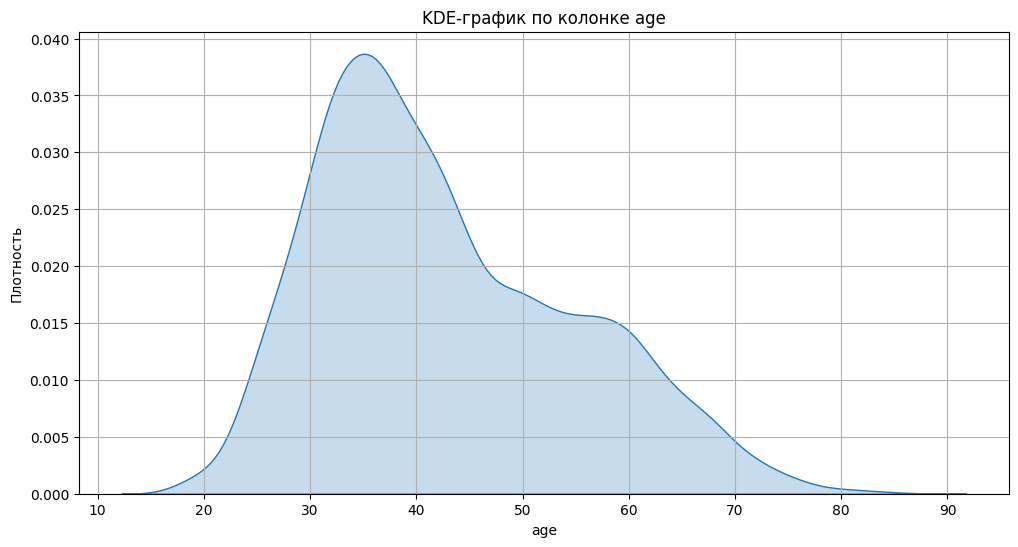

'Доля пользователей возраста 30 - 40: 39.59%'

In [24]:
kde_plot(data, 'age')

display('Доля пользователей возраста 30 - 40: {}%'
        .format(group_level(data, 'age', 30, 40))
       )

**Промежуточный итог:** 35 лет - возраст ~4% пользователей.

Основная доля клиентов банка: люди от 30 до 40 лет - таких 40% клиентов.

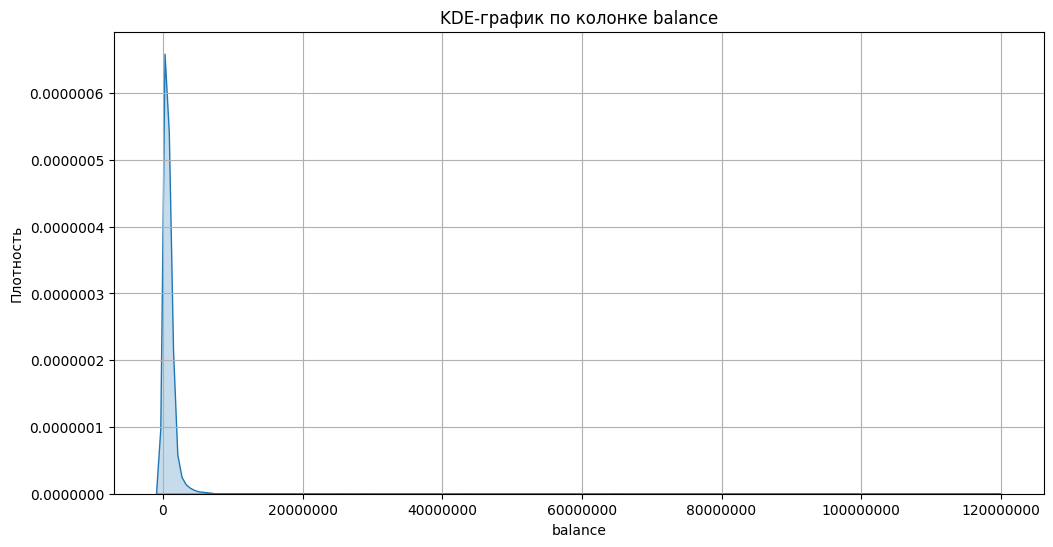

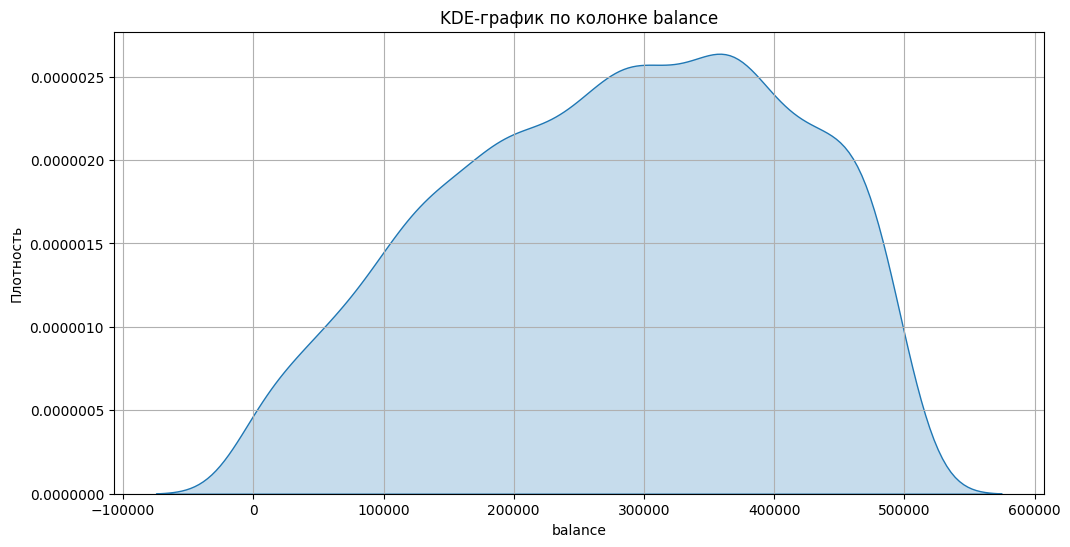

'Доля пользователей с балансом 200000 - 750000: 26.27%'

'Доля пользователей с балансом 280000 - 380000: 9.89%'

In [25]:
kde_plot(data, 'balance')

kde_plot(data.query('balance < 500000'), 'balance')

display('Доля пользователей с балансом 200000 - 750000: {}%'
        .format(group_level(data, 'balance', 200000, 500000))
       )


display('Доля пользователей с балансом 280000 - 380000: {}%'
        .format(group_level(data, 'balance', 280000, 380000))
       )

**Промежуточный итог:** отдельно по отдельной сумме на балансе сложно оценить пользователей, но есть возможность оценить по пику нижней и верхней границе баланса: от 280 тыс. до 380 тыс. рублей - всего таких клиентов 10%.


Дополнительно можно отметить пользователей по уровню баланса от 250 тыс. до 500 тыс. рублей - таких пользователей 26%.

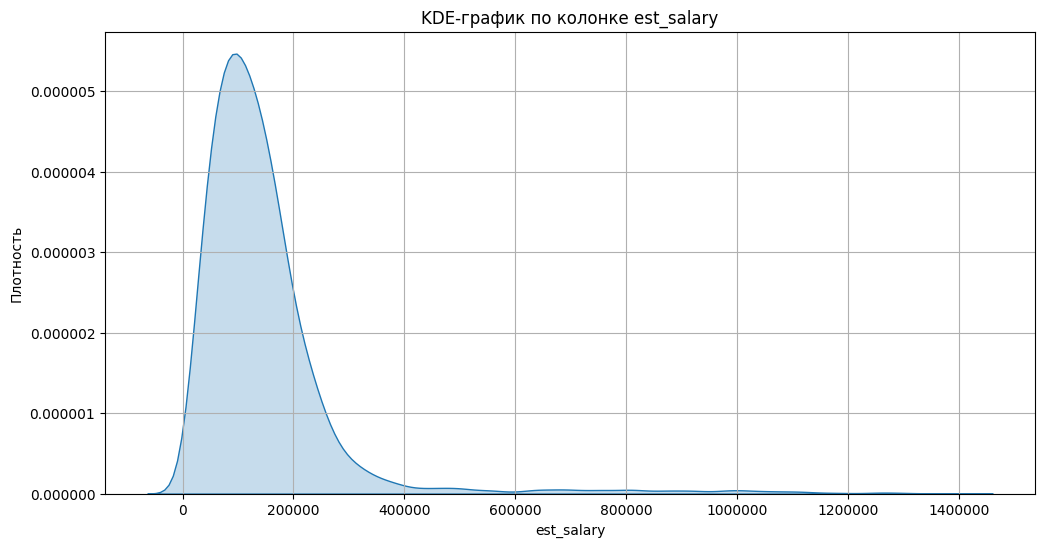

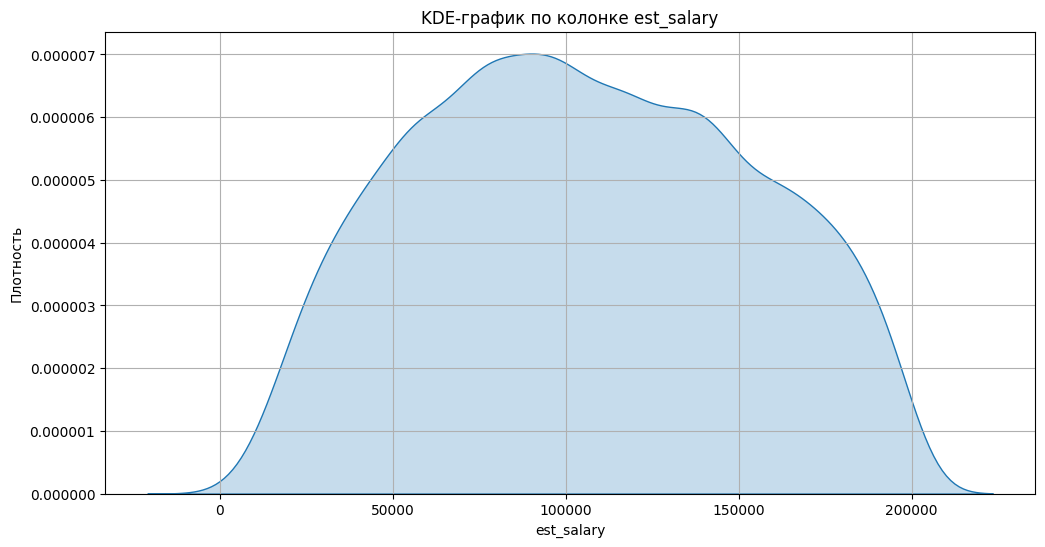

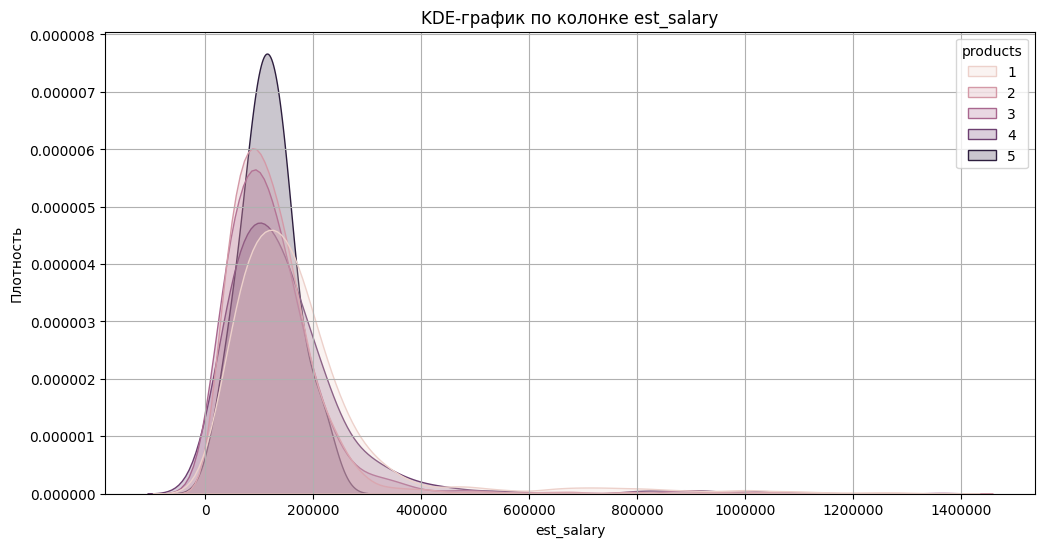

'Доля пользователей с зп 70000 - 200000: 60.64%'

In [26]:
kde_plot(data, 'est_salary')

kde_plot(data.query('est_salary < 200000'), 'est_salary')

kde_plot(data, 'est_salary', 'products')

display('Доля пользователей с зп 70000 - 200000: {}%'
        .format(group_level(data, 'est_salary', 70000, 200000))
       )

**Промежуточный итог:** большинство пользователей по оценочной зп находится в районе от 70 тыс. до 100 тыс. рублей - 61% данных клиентов.

Наибольшая заработная плата у пользователей с бОльшим количеством продуктов - пик таких пользователей находится от 100 тыс. рублей.

### Вывод по типичным клиентам

Были рассмотрены распределения клиентов по категориальным, количественным значениям и средних значений:
- **По категориальным значениям:**
    - По полу и активности распределение одинаковое (50 на 50);
    - Большинство пользователей из Ярославля и Рыбинска (58% и 27% соответсвенно);
    - Четверть клиентов имеют оценку собственности 0, по 19% имеют среднюю оценку - 4 и 5;
    - Более половины (52%) имеют два продукта банка, 33% - 1 продукт;
    - У 68% клиетов есть кредитная карта;
- **По количественным значениям:**
    - Большинство пользователей находится на уровне от 800 до 900 баллов кредитного скоринга - 54% пользователей;
    - Пик по баллам скоринга в Ростове отличается и находится на уровне 800;
    - Основная доля клиентов банка: люди от 30 до 40 лет - таких 40% клиентов;
    - Пик по балансу: от 280 тыс. до 380 тыс. рублей - всего таких клиентов 10%, а большинство клиентов имеют от 250 тыс. до 500 тыс. рублей - таких пользователей 28%;
    - Большинство пользователей по оценочной зп находится в районе от 70 тыс. до 100 тыс. рублей - 63% данных клиентов;

**Первичное определение типовых клиентов:**

- **Из очевидного про типичного клиента:**
    - Находится в Ярославле или Рыбинске;
    - Имеют кредитную карту;
    - Имеют доход от 70 тыс. до 100 тыс. рублей;
    - Возраст 30 - 40 лет;
    - Имеют до 2 продуктов банка;
- **Из менее очевидного про типичного клиента:**
    - Баллы кредитного скоринга от 800 до 900;
    - Баланс от 280 тыс. до 380 тыс. рублей.

### Анализ отточных клиентов

#### Распределение категориальным признакам

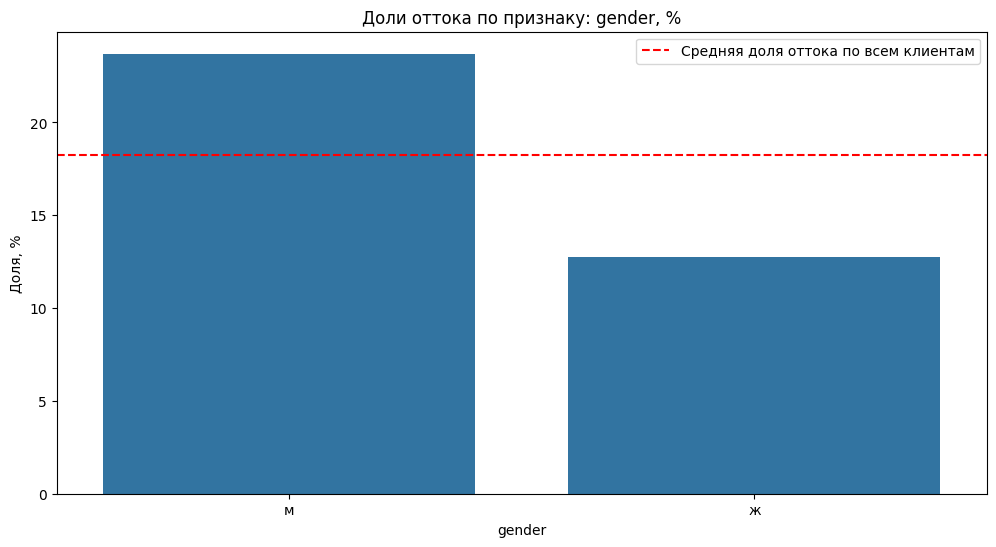

In [27]:
def bar_plot(df, attribute):

    #уровень оттока по всей таблице
    churn_rate = df['churn'].mean() * 100

    #формирую таблицу для подсчета доли оттока
    df_bar = df.groupby(attribute, as_index=False).agg({'churn':'mean'})
    df_bar['churn'] = df_bar['churn'] * 100
    df_bar = df_bar.sort_values('churn', ascending=False)
    #проверка на два значения: 0 и 1
    unique_values = df[attribute].unique()
    if set(unique_values) == {0, 1}:
        mapping = {0: 'Нет', 1: 'Да'}
        df_bar[attribute] = df_bar[attribute].map(mapping)

    plt.figure(figsize=(12, 6))
    sns.barplot(y='churn', x=attribute, data=df_bar)
    plt.axhline(y=churn_rate, linestyle='--', label='Средняя доля оттока по всем клиентам', color='r')

    plt.xlabel(f'{attribute}')
    plt.ylabel('Доля, %')
    plt.title(f'Доли оттока по признаку: {attribute}, %')
    plt.legend()

    plt.show()

bar_plot(data, 'gender')

**Промежуточный итог:** все категориальные даты будут рассмотрены с общей долей оттока. Общая доля оттока по клиентам - 18%.

Отток по полу:
- Мужчины: более 20% отточных;
- Женщины: более 10% отточных.

Среди мужчин довольно большая часть отточных (больше, чем по всем данным).

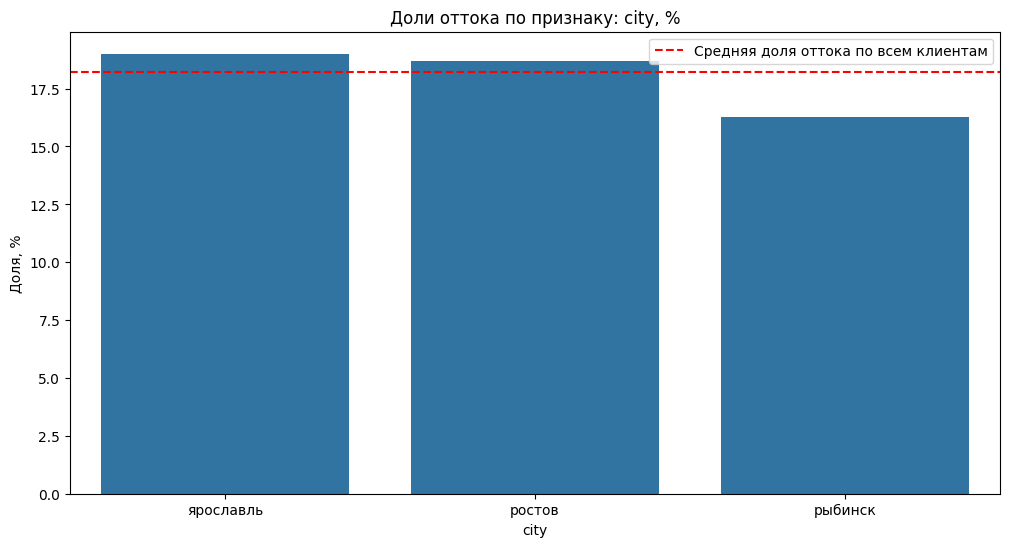

In [28]:
bar_plot(data, 'city')

**Промежуточный итог:**

Отток по городу:
- Ярославль: более 19% оттока;
- Ростов: более 18% оттока;
- Рыбинск: менее 17% оттока.

Менее отточный город - Рыбинск, в данном городе менее 17% отточных клиентов (меньше, чем в среднем).

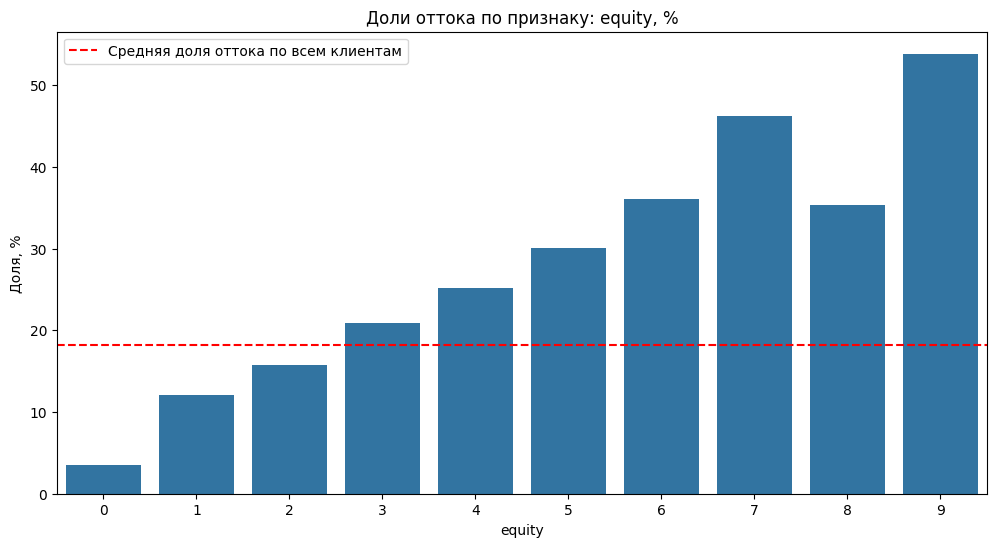

In [29]:
bar_plot(data, 'equity')

**Промежуточный итог:**

Отток по оценкам:
- Оценка 9: наиболее отточная - более 50%;
- Оценка 7: более 45% оттока;
- Оценки 6 и 8: более 35% оттока по каждой оценке;
- Оценки 5, 4 и 3: доля оттока 30%, 25% и 20% соответственно.

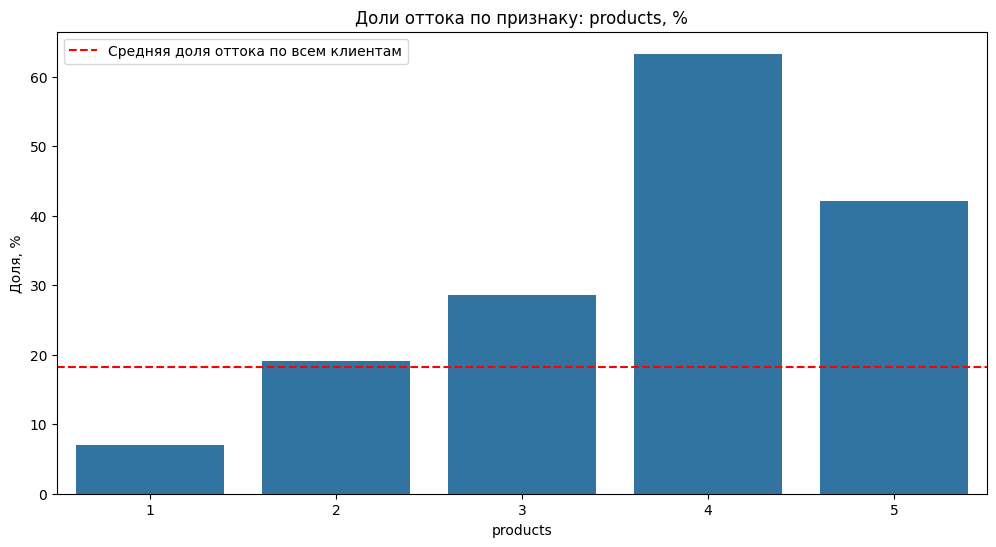

In [30]:
bar_plot(data, 'products')

**Промежуточный итог:**

Отток по количеству продуктов:
- 4 продукта: более 60% оттока;
- 5 продуктов: более 40% оттока;
- 3 продукта: до 30% оттока.

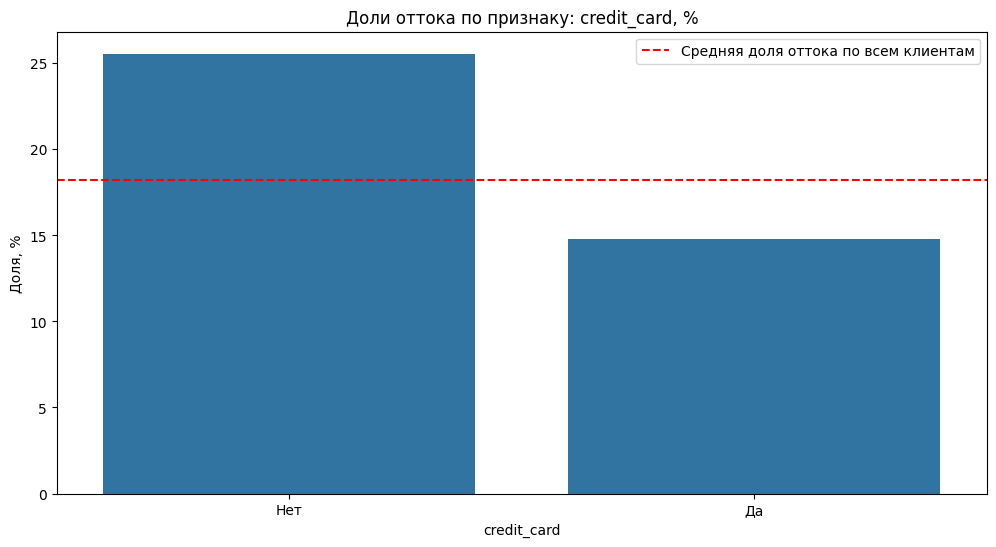

In [31]:
bar_plot(data, 'credit_card')

**Промежуточный итог:**

Отток по наличию кредитной карты:
- Нет кредитной карты: 25% оттока;
- Есть кредитная карта: 15% оттока.

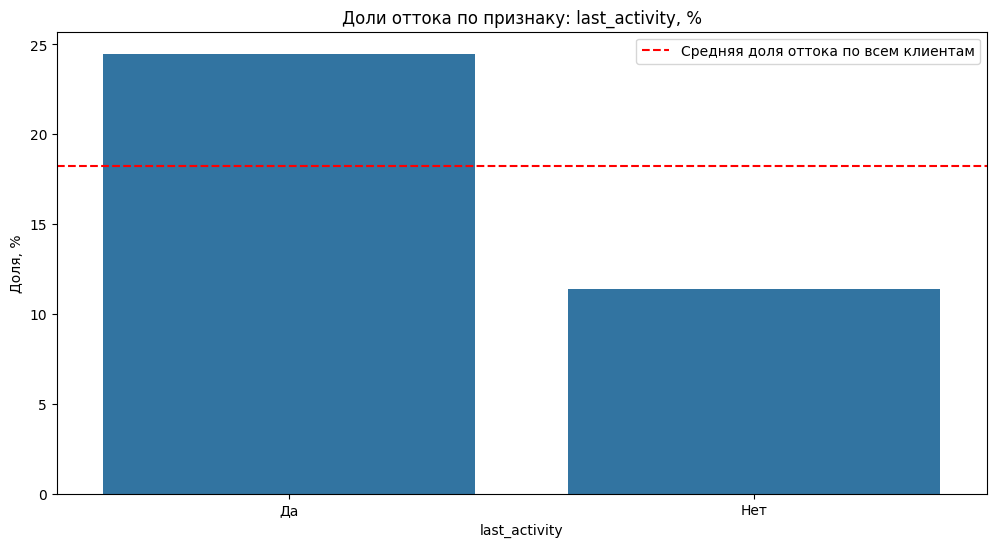

In [32]:
bar_plot(data, 'last_activity')

**Промежуточный итог:**

Отток по последней активности:
- Был активен в последнее время: до 25% оттока;
- Не был активен в последнее время: более 10% оттока.

#### Распределение по количественным признакам

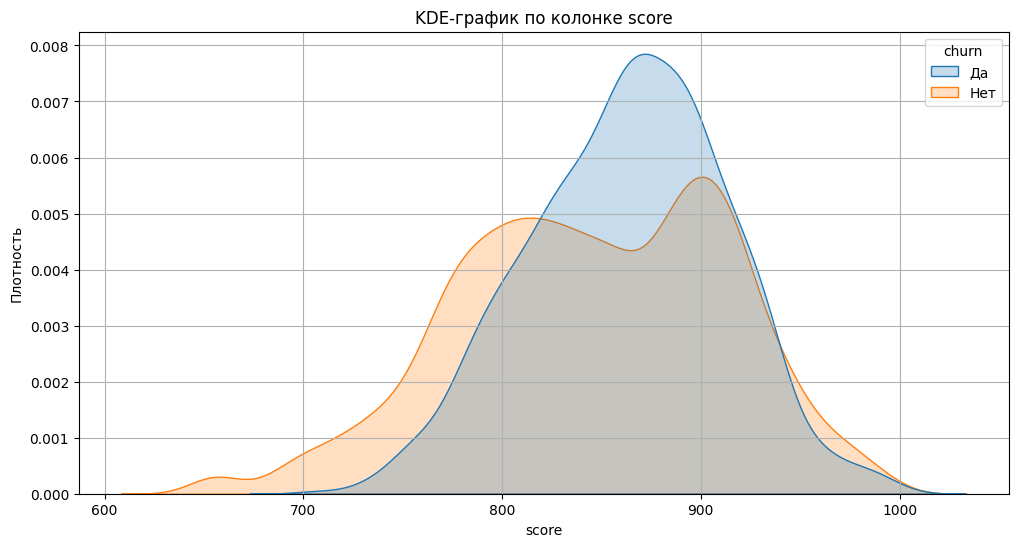

In [33]:
kde_plot(data, 'score', 'churn')

**Промежуточный итог:**

Доля отточных выше на праспределениях по баллам:
- Баллы кредитного скорринга 820 - 900: выше всего доля отточных клиентов на промежутке;
- Баллы кредитного скорринга 900 - 940: доля отточных выше, но разница между оставшимися минимальна.

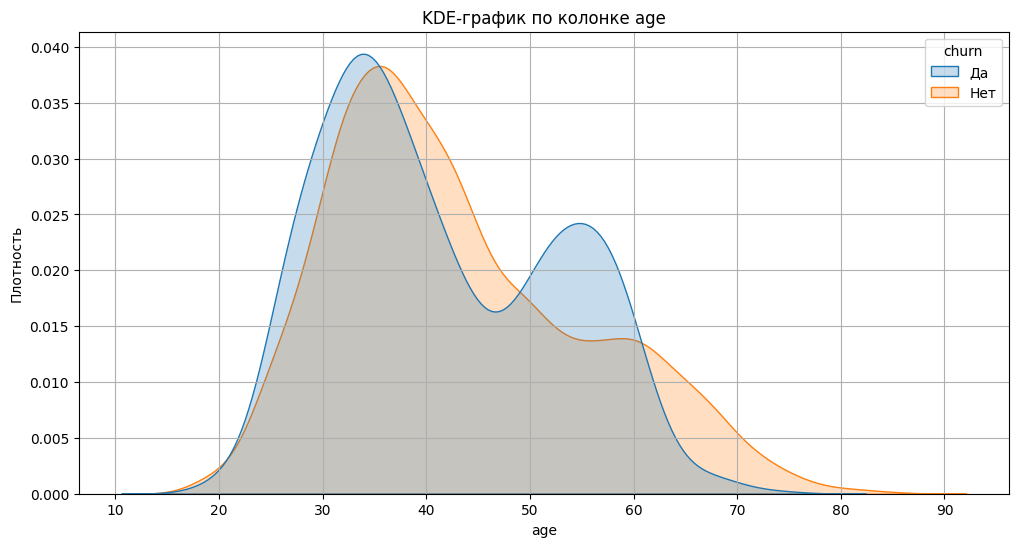

In [34]:
kde_plot(data, 'age', 'churn')

**Промежуточный итог:**

Доля отточных выше на праспределениях по возрасту:
- Возраст 49 - 60;
- Возраст 23 - 35.

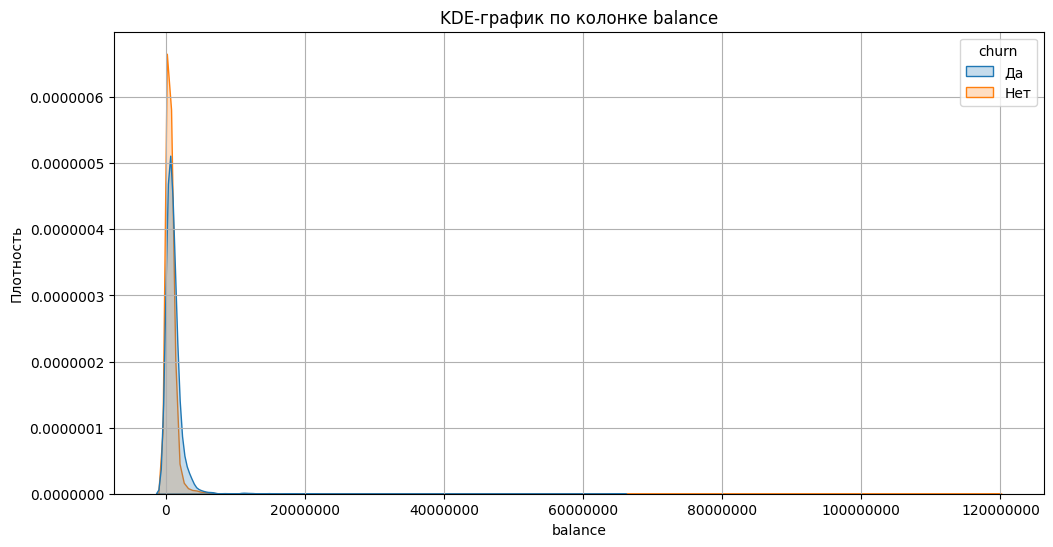

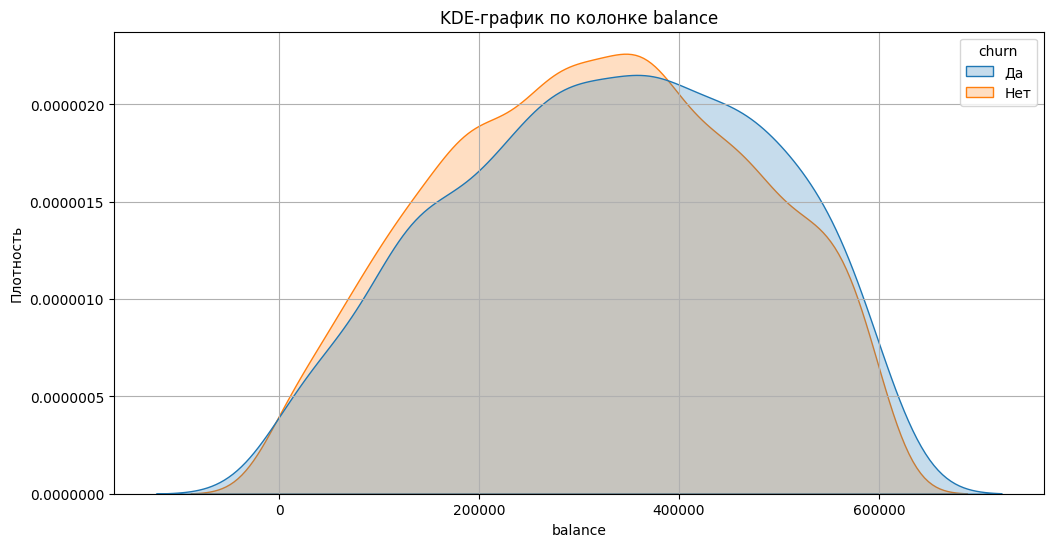

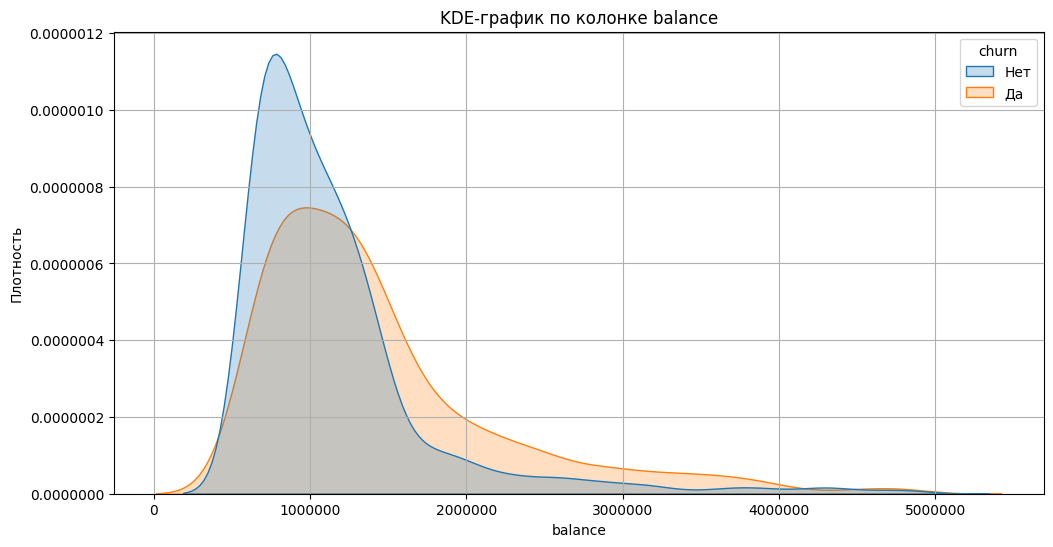

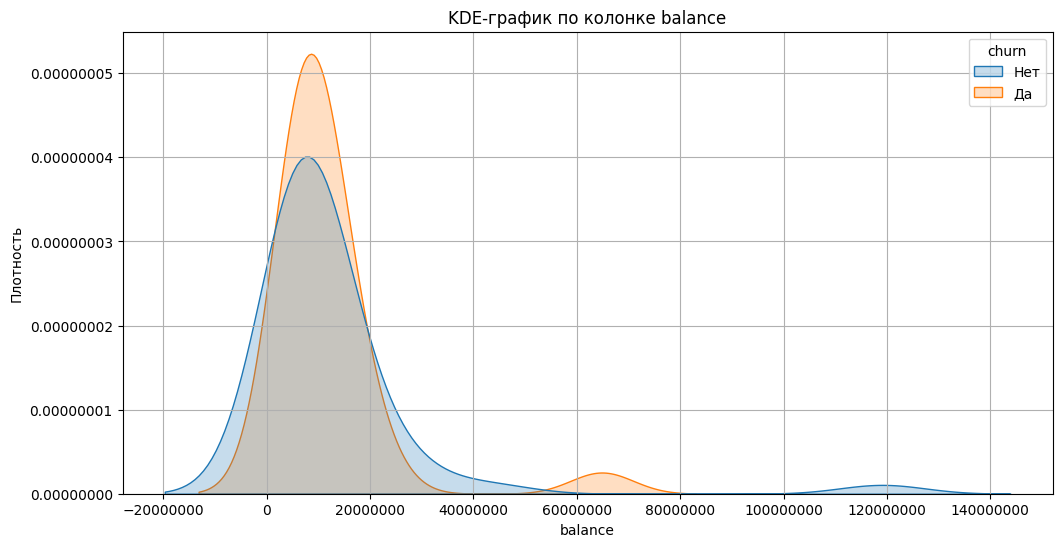

In [35]:
kde_plot(data, 'balance', 'churn')

kde_plot(data.query('balance < 600000'), 'balance', 'churn')

kde_plot(data.query('balance < 5000000 and balance >= 600000'), 'balance', 'churn')

kde_plot(data.query('balance >= 5000000'), 'balance', 'churn')

**Промежуточный итог:**

Доля отточных выше на праспределениях по балансу:
- 400 тыс. - 600 тыс. рублей;
- 1.3 млн. - 5 млн. рублей;
- 7 млн. - 19 млн. рублей;
- 68 млн. - 80 млн. рублей.

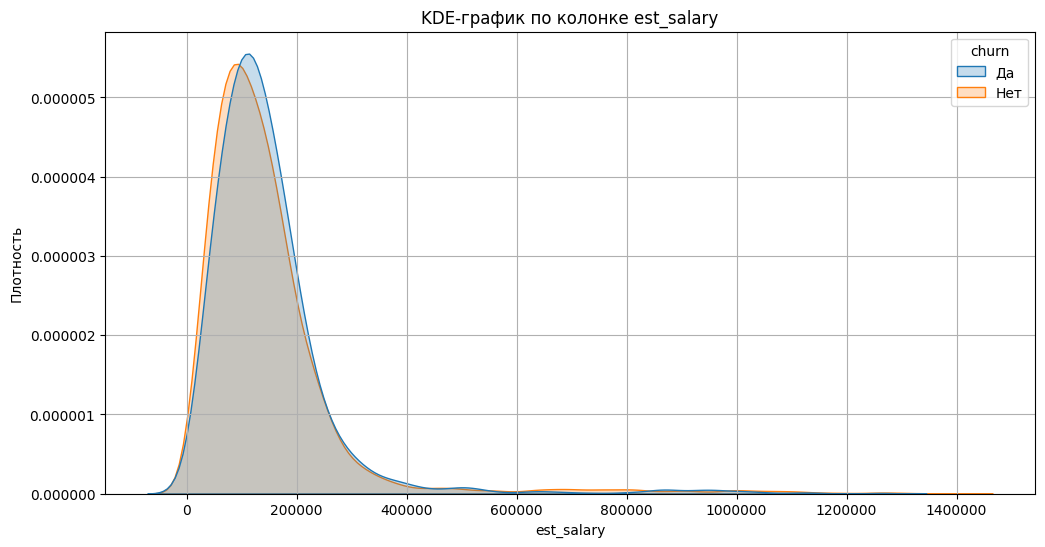

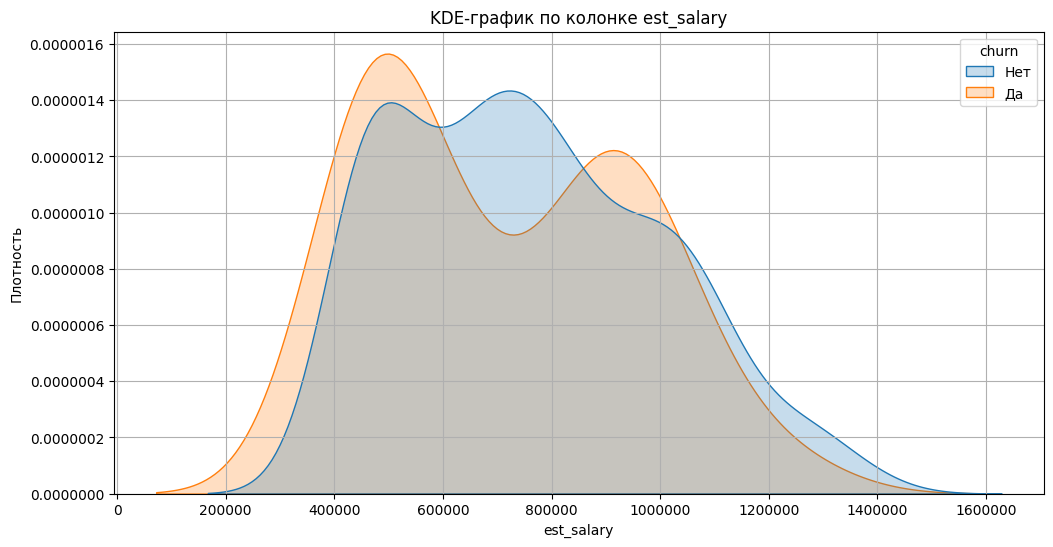

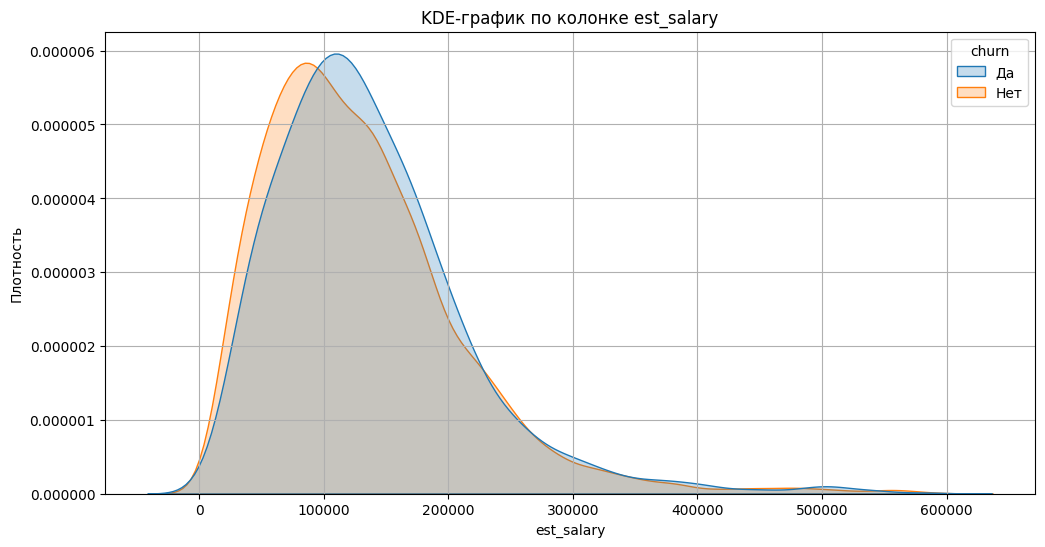

In [36]:
kde_plot(data, 'est_salary', 'churn')

kde_plot(data.query('est_salary > 400000'), 'est_salary', 'churn')

kde_plot(data.query('est_salary < 600000'), 'est_salary', 'churn')

**Промежуточный итог:**

Доля отточных выше на праспределениях по оценочной заработной плате:
- Зп от 100 тыс. до 600 тыс. рублей;
- Зп 830 тыс. - 1 млн. рублей.

### Вывод по отточным клиентам

Проведено количественное и качественное исследование отточных клиентов, отметим интересные и важные моменты:

- Общий отток по банку - 18% клиентов;
- 20% мужчин отточные;
- Из Ярославля и Ростова по более 19% и 18% отточных;
- Оценки 9 и 7 более 50% и 45% отточных соответственно. Менее отточные оценки: 8 и 6 - 35% оттока, 5, 4 и 3 - 30%, 25% и 20% оттока соответственно;
- 4 продукта у клиента: доля отточных превышает 60% клиентов. Менее отточные: 5 и 3 продукта - 40% и 30% соответственно;
- Из тех, у кого нет кредитной карты, 25% отточных;
- Из активных до 25% отточные;
- По баллам кредитного скоринга от 820 до 900 выше всего доля отточных клиентов;
- По возрасту доля отточных выше на промежутках: 23 - 35, 49 - 60;
- Баланс: 400 тыс. - 600 тыс. рублей, 1.3 млн. - 5 млн. рублей, 7 млн. - 19 млн. рублей, 68 млн. - 80 млн. рублей - доля оттока выше;
- Доля отточных выше на праспределениях по оценочной заработной плате: 100 тыс. - 600 тыс. и 830 тыс. - 1 млн. рублей.
    
В целом по некоторым аспектам отточные клиенты действительно отличаются от остальных.

Но для убеждения в различиях и более уверенного формирования портретов типичных клиентов далее стоит рассмотреть корреляции, а также средние значения по всем признакам.

### Корреляционный анализ

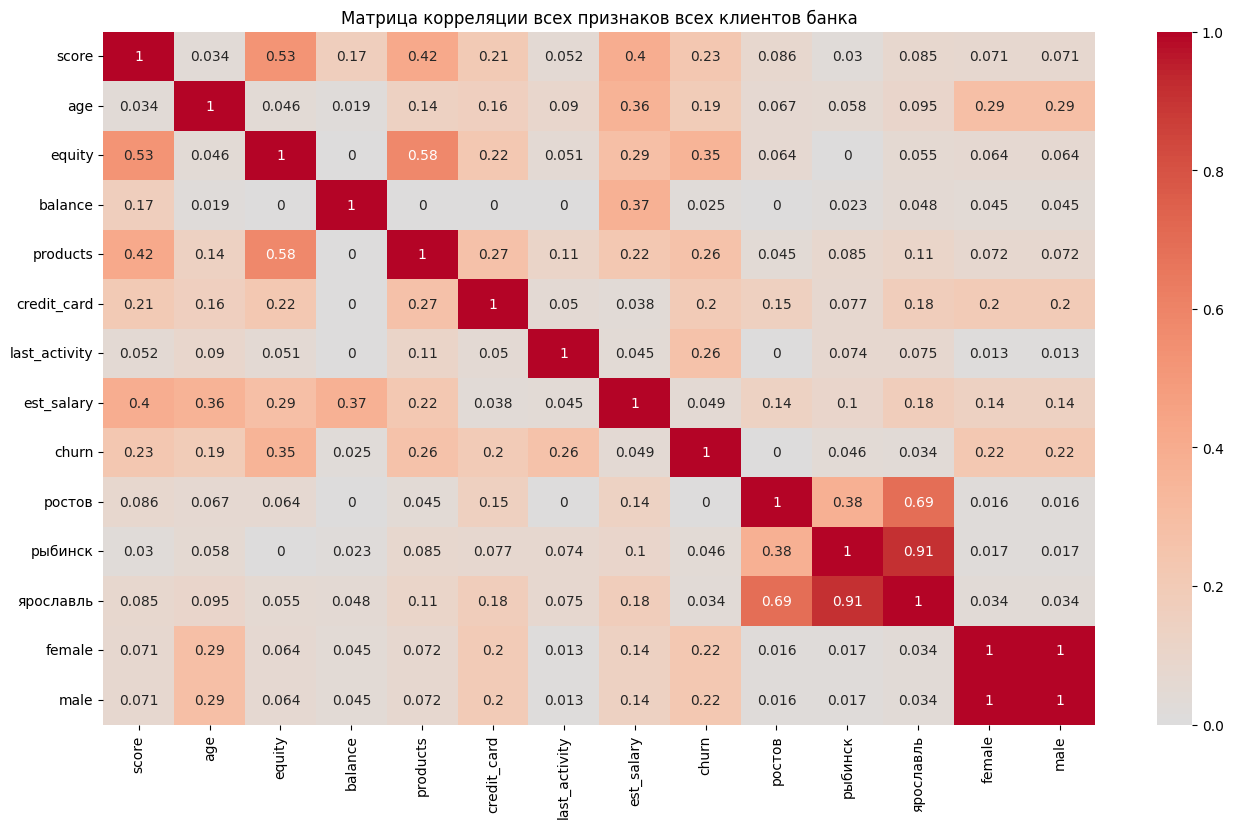

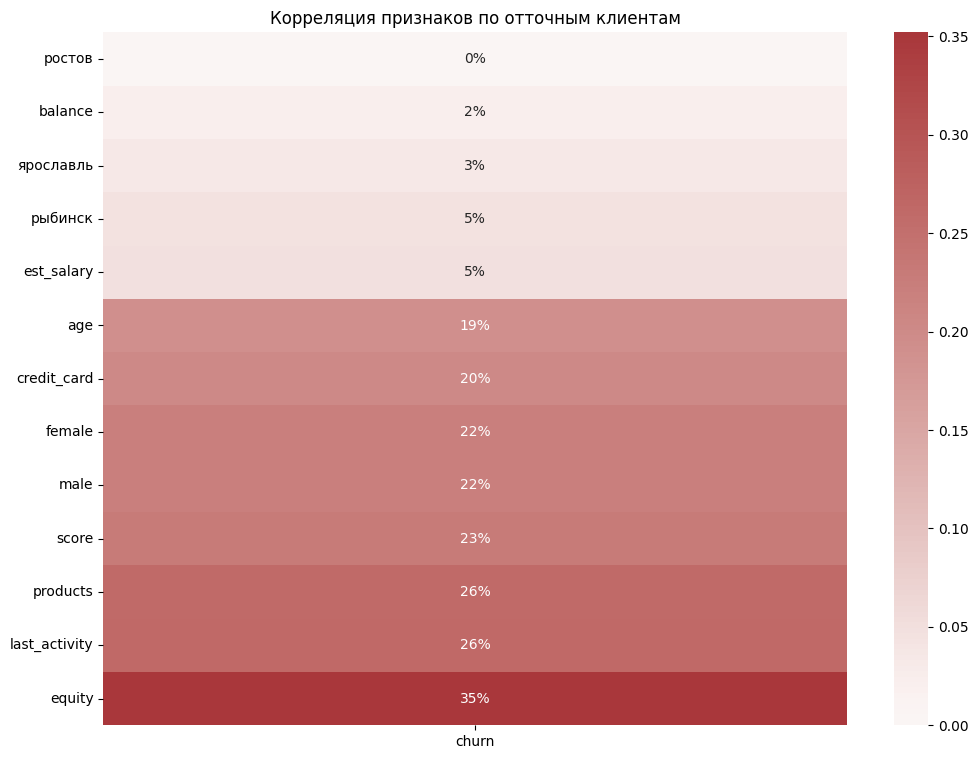

In [37]:
plt.figure(figsize=(16, 9))

#дропаю категориальные значения и передаю непрервные
sns.heatmap(
            data.drop(['city', 'gender', 'userid', 'have_null'], axis=1)
            .phik_matrix(interval_cols=['score', 'age', 'balance', 'est_salary']),
            cmap='coolwarm',
            center=0,
            annot=True
           )

plt.title('Матрица корреляции всех признаков всех клиентов банка')

plt.show()

plt.figure(figsize=(12, 9))

sns.heatmap(
            data
            .drop(['city', 'gender', 'userid', 'have_null'], axis=1)
            .phik_matrix(interval_cols=['score', 'age', 'balance', 'est_salary'])
            .loc[:,['churn']].drop('churn')
            .sort_values('churn'), annot=True, fmt=".0%", cmap="vlag", center=0
           )

plt.title('Корреляция признаков по отточным клиентам')

plt.show()

**Промежуточный итог:** стоит отметить, что в таблице не обнаружено, сильно влияющих на отток, значений.

Можно отметить наиболее коррелирующее значение с оттоком - приблизительную оценку собственности клиента. На данный момент оценка имеет коэффициент корреляции 0.35, что говорит о корреляции, но слабой. Чем больше у клиента оценка, тем выше вероятность оттока.

Дополнительные коррелирующие значения (с коэффициентом по 0.26):
- Количество продуктов;
- Последняя активность.

### Формирование портетов клиентов

In [38]:
#создаю таблицу для подсчета средних и моды
typical_clients = (
                   data
                   .groupby('churn', as_index=False)
                   .agg({
                       'score': 'mean', #это среднее
                       'city': pd.Series.mode, #а это мода
                       'gender': pd.Series.mode,
                       'age': 'mean',
                       'equity':'mean',
                       'balance': 'mean',
                       'products': 'mean',
                       'credit_card': pd.Series.mode,
                       'last_activity': pd.Series.mode,
                       'est_salary': 'mean'
                       })
                   )


#смотрю разницу только по числовым значениям
num_cols = typical_clients.select_dtypes(include=['int64', 'float64']).columns

#формирую разницу
diff = (
        typical_clients.loc[typical_clients['churn'] == 1, num_cols].values[0] -
        typical_clients.loc[typical_clients['churn'] == 0, num_cols].values[0]
       )

#разница в %
perc_diff = (
             diff /
             typical_clients.loc[typical_clients['churn'] == 0, num_cols].values[0]
            ) * 100

#формирую табличку
perc_diff_df = pd.DataFrame(data=perc_diff, index=num_cols, columns=['Разница групп, %'])


display(typical_clients.T)
display(perc_diff_df)

,0,1
churn,0,1
score,845.40,863.36
city,ярославль,ярославль
gender,ж,м
age,43.02,41.43
equity,2.38,3.76
balance,733031.63,1134458.21
products,1.76,2.38
credit_card,1,1
last_activity,0,1


,"Разница групп, %"
churn,inf
score,2.13
age,-3.70
equity,58.24
balance,54.76
products,35.16
credit_card,0.00
last_activity,inf
est_salary,0.46


**Промежуточный итог:** были рассмотрены средние признаки в разрезе оттока, отметим результаты:
- **Отличия клиентов**:
    - Чаще отточные клиенты - мужчины, а оставшиеся наоборот;
    - Оценка собственности у отточных клеинтов выше и составляет от 3 до 4, у оставшихся оценка на уровне 2 - 3;
    - Баланс у отточных клиентов выше более, чем на 50% (1.1 млн. руб. в среднем), чем у оставшихся (700 тыс. руб. в среднем);
    - И продуктов у отточных клиентов больше: в среднем 2 - 3 продукта, когда у оставшихся до 2 продуктов банка;
- **Схожесть клиентов**:
    - Средний балл крединого скоринга доходит до 860;
    - Большинство находятся в Ярославле;
    - Возраст в среднем ~40 лет;
    - Имеют кредитную карту;
    - Оценочна заработная плата находится на уровне ~150 тыс. руб.

### Выводы по анализу и построение портретов клиентов

Проведен исследовательский анализ данных по различным группам клиентов, далее отметим интересные/ключевые моменты анализа:

В основном весь анализ рассматривался по группам клиентов с признаком: отточный и оставшийся клиент банка.

**Итоги по распределению пользователей:**
- **Типичный клиент:**
	- Находится в Ярославле (59% клиентов) или Рыбинске (27% клиентов);
	- Четверть (26%) пользователей имеют оценку собственности 0. По 19% клиентов с оценкой 5 и 4;
	- Имеет до 2 продуктов (51% с 2 продуктом, 33% с 1 продуктом);
	- Чаще у клиента есть кредитные карты - 68%;
	- Возраст от 30 до 40 (40% клиентов);
	- 800 - 900 баллов кредитного скоринга (52% клиентов);
	- С балансом 200 тыс. - 750 тыс. рублей: 26% клиентов;
	- Зп 70 тыс. - 200 тыс. рублей: 61%;
	- Пол, активность могут не иметь значения для типичного клиента;
- **Отточные клиенты:**
	- Общий отток по банку - 18% клиентов;
	- 20% мужчин отточные;
	- Из Ярославля и Ростова по более 19% и 18% отточных;
	- Оценки 9 и 5 более 50% и 45% отточных соответственно;
	- 4 продукта у клиента: доля отточных превышает 60% клиентов;
	- Из тех, у кого нет кредитной карты, 25% отточных;
	-  Из активных до 25% отточные;
	- По баллам кредитного скоринга от 820 до 900 выше всего доля отточных клиентов;
	- По возрасту доля отточных выше на промежутках: 23 - 35, 49 - 60;
	- Баланс: 400 тыс. - 600 тыс. рублей - доля оттока выше;
	- Доля отточных выше на праспределениях по оценочной заработной плате: до 600 тыс. и 830 тыс. - 1 млн. рублей.
    
**Итоги по корреляционному анализу:**
- Сильных корреляций с оттоком <u>не выявлено</u>;
- **Наиболее** коррелирующий признак с оттоком (слабый уровень): приблизительная оценка собственности клиента. Чем выше данный показатель, тем выше вероятность оттока;
- **Наименее** коррелирующие признаки с оттоком (очень слабый уровень):
	- Последняя активность;
	- Количество продуктов;
	- Баллы кредитного скоринга;
	- Пол клиента.
    
**Портреты типичных клиентов:**
- **Общие признаки:**
	- Находится в Ярославле;
	- Баллы кредитного скоринга от 820 до 870;
	- Возраст клиента 35 - 42 лет;
	- Есть кредитная карта;
	- Оценочная зп на уровне 150 тыс. руб;
- **Оставшийся:**
    - Чаще всего с оценкой 0, 4 и 5;
	- Имеют до 2 продуктов банка;
	- Баланс у клиентов на уровне 600 тыс. руб;
- **Отточный:**
	- Чаще всего мужчина;
	- Оценка пользователей чаще всего 4 и 5;
	- Имеют до 3 продуктов банка;
	- Баланс клиентов на уровне до 1.1 млн. руб;
	- Дополнительный пик по клиентам с возрастом 52 - 57 лет;
	- Активны в последнее время.

    
В дальнейшем данные портреты и другие выводы, в т.ч. распределения и корреляции, будут использоваться для формирования и анализа отдельных сегметов пользователей.

## Формулировка гипотез и их проверка

### Доход между теми клиентами, которые ушли и теми, которые остались, различается

Перед тем, как проверять гипотезы, выдвенем их:

- Нулевая гипотеза: между отточными и оставшимися клиентами доход **одинаковый**;
- Альтернативная гипотеза: доход отточных и оставшихся клиентов **различается**.

Пороговое значение alpa будем использовать 0.05.

Данные гипотезы проверим t-критерием и u-критерием, и объясним расхождения, если они возникнут.

Для начала обозначим требования к данным для критериев:
- t-критерий используется при условии:
    - Выборки нормально распределены в разрезе исследуемого значений;
    - Участвует большая выборка в распределениях;
- u-критерий используется при условии:
    - Нет возможность предположить о нормальности распределения в группах;
    - Есть выбросы в данных.

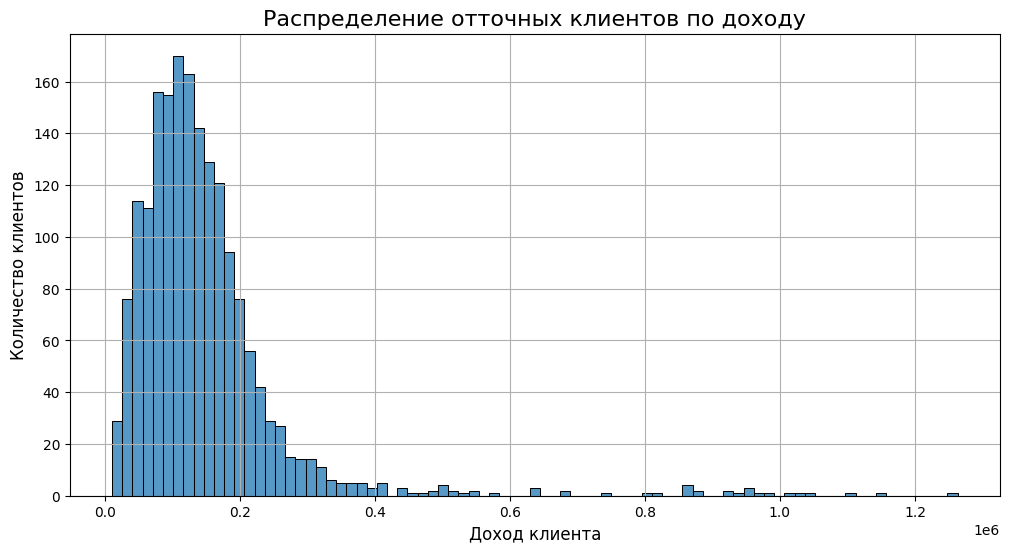

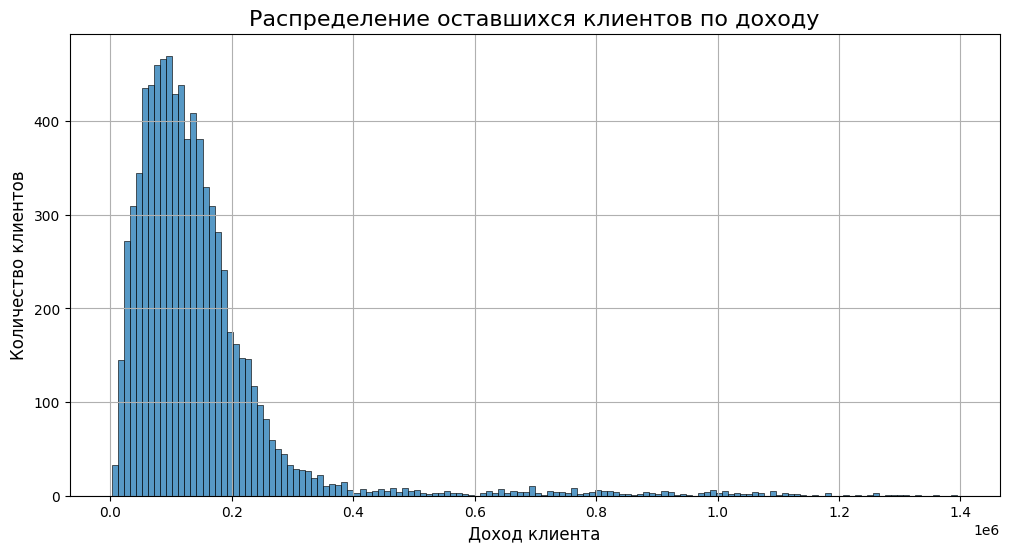

In [39]:
#формирую таблицы
data_churn = data.query('churn == 1')

data_unchurn = data.query('churn != 1')

plt.figure(figsize=(12, 6))

sns.histplot(data=data_churn, x='est_salary')

plt.xlabel('Доход клиента', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.title('Распределение отточных клиентов по доходу', fontsize=16)
plt.grid(visible=True)

plt.show()

plt.figure(figsize=(12, 6))

sns.histplot(data=data_unchurn, x='est_salary')

plt.xlabel('Доход клиента', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.title('Распределение оставшихся клиентов по доходу', fontsize=16)
plt.grid(visible=True)

plt.show()

Распределение похожи на нормальные по двум группам, но оба распределния сильно смещены влево.

Перед тем, как проверять гипотезы, выдвенем еще одну по поводу нормальности распределения:
- Нулевая гипотеза: распределение не нормально;
- Альтернативная гипотеза: распределение нормально.

Пороговое значение alpa будем использовать 0.05.

А проверять гипотезы будем методом Шапиро-Уилка.

In [40]:
score_norm = st.shapiro(data['score'])

alpha = 0.05

display('p-value: {0:.3f}'.format(score_norm[1]))

if score_norm[1] < alpha:
    display('Отвергаем нулевую гипотезу: распределение не нормально')
else:
    display('Не получилось отвергнуть нулевую гипотезу, всё нормально')

'p-value: 0.000'

'Отвергаем нулевую гипотезу: распределение не нормально'

Итак, критерий Шапиро-Уилка показал, что мы не может быть убеждены в нормальности распределения.

В любом случае, для проверки будет использовать два критерия, но применять к выводам только один - u-критерий.

In [41]:
#использую двустороннюю гипотезу
salary_diff_t = st.ttest_ind(data_churn['est_salary'], data_unchurn['est_salary'])
salary_diff_u = st.mannwhitneyu(data_churn['est_salary'], data_unchurn['est_salary'])

display('--- Значения по t-критерию ---')

display('p-value: {}'.format(salary_diff_t.pvalue))

if salary_diff_t.pvalue < alpha:
    display('Отвергаем нулевую гипотезу - между клиентами есть разница по доходу')
else:
    display('Не получилось отвергнуть нулевую гипотезу, нет оснований считать доход клиентов по оттоку разными')

print("\n")

display('--- Значения по u-критерию ---')

display('p-value: {0:.3f}'.format(salary_diff_u.pvalue))

if salary_diff_u.pvalue < alpha:
    display('Отвергаем нулевую гипотезу - между клиентами есть разница по доходу')
else:
    display('Не получилось отвергнуть нулевую гипотезу, нет оснований считать доход клиентов по оттоку разными')

'--- Значения по t-критерию ---'

'p-value: 0.8500882387258035'

'Не получилось отвергнуть нулевую гипотезу, нет оснований считать доход клиентов по оттоку разными'

'--- Значения по u-критерию ---'

'p-value: 0.000'

'Отвергаем нулевую гипотезу - между клиентами есть разница по доходу'

**Промежуточный итог:** возникла разница в результатах двух критерий, все потому, что при условиях нормального распределения, t-критерий более точно определяет ситуацию, а u-критерий нацелен на изучение ненормальных распределений и наличии выбросов.

Так как до этого не убедились в нормальности распределения, то будем использовать выводы по u-критерию: отвергаем нулевую гипотезу - между клиентами есть разница по доходу.

### Баллы кредитного скоринга между теми клиентами, которые ушли и теми, которые остались, одинаковы

Так же выдвенем гипотезы перед их проверкой:
- Нулевая гипотеза: баллы кредитного скоринга между теми клиентами, которые ушли и теми, которые остались, одинаковы
- Альтернативная гипотеза: баллы кредитного скоринга между отточными и оставшимися клиентами разные.

Пороговое значение alpa будем использовать 0.05.

Посмотрим на распределение, а далее выберем подходящий критерий для проверки.

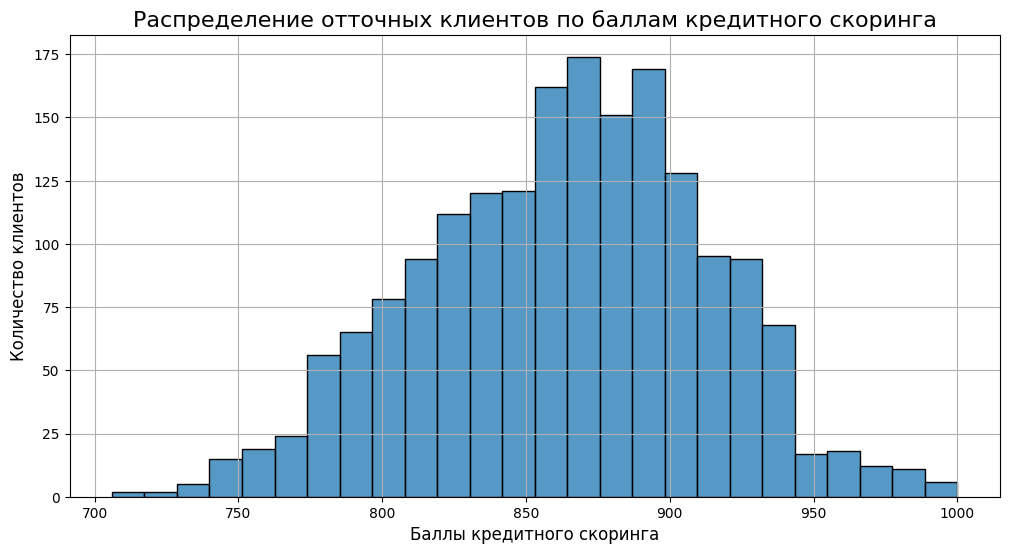

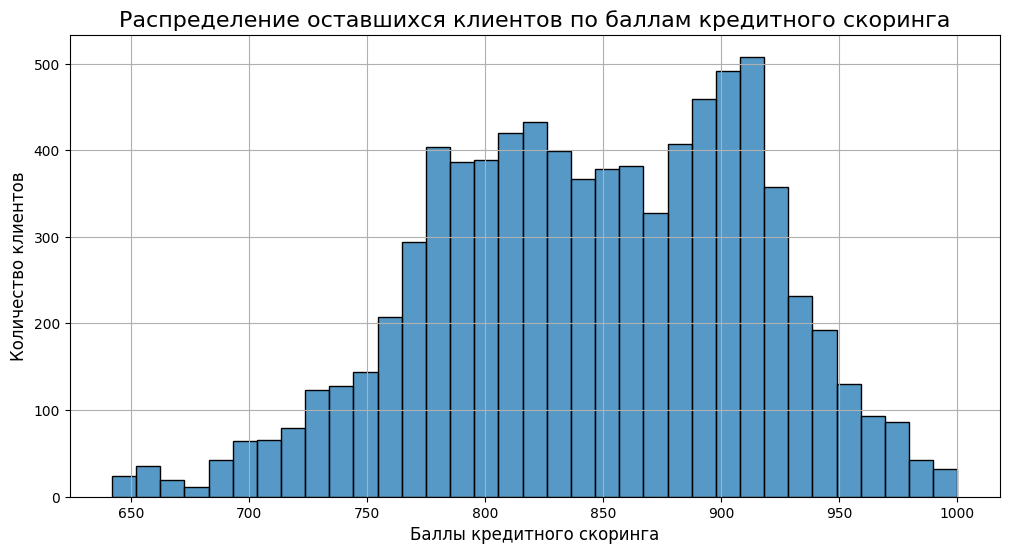

In [42]:
plt.figure(figsize=(12, 6))

sns.histplot(data=data_churn, x='score')

plt.xlabel('Баллы кредитного скоринга', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.title('Распределение отточных клиентов по баллам кредитного скоринга', fontsize=16)
plt.grid(visible=True)

plt.show()

plt.figure(figsize=(12, 6))

sns.histplot(data=data_unchurn, x='score')

plt.xlabel('Баллы кредитного скоринга', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.title('Распределение оставшихся клиентов по баллам кредитного скоринга', fontsize=16)
plt.grid(visible=True)

plt.show()

Распределения явно отличаются:
- У отточных клиентов нормальное распределение;
- У оставшихся клиентов не похоже на нормальное распределение.

Поэтому дальше для проверки будем использовать только один критерий - u-критерий.

In [43]:
score_diff = st.mannwhitneyu(data_churn['score'], data_unchurn['score'])

display('p-value: {0:.3f}'.format(score_diff.pvalue))

if score_diff.pvalue < alpha:
    display('Отвергаем нулевую гипотезу - между клиентами есть разница по рейтингу')
else:
    display('Не получилось отвергнуть нулевую гипотезу, нет оснований считать рейтинг клиентов по оттоку разными')

'p-value: 0.000'

'Отвергаем нулевую гипотезу - между клиентами есть разница по рейтингу'

**Промежуточный итог:** здесь использовали u-критерий, так как распределение по рейтингу оставшихся клиентов не является нормальным.

Исходя из u-критерия мы можем отвергнуть нулевую гипотезу и предположить, что между отточными и оставшимися клиентами есть разница по рейтингу.

### Итог по проверке гипотез

Всего было проверено две гипотезы:
- Доход между теми клиентами, которые ушли и теми, которые остались, различается:
    - Использовал t-критерий;
    - Нет оснований считать доход клиентов по оттоку разными;
- Баллы кредитного скоринга между теми клиентами, которые ушли и теми, которые остались, одинаковы:
    - Использовал u-критерий;
    - Отвергаем нулевую гипотезу, между группами есть разница по рейтингу.

##  Сегментация клиентов

После исследовательского анализа можно отметить, на что именно нужно обратить внимание для сегментации пользователей с определенной долей оттока:
- Возраст 52 - 57 лет;
- Были активны в последнее время;
- Мужчины;
- 3 - 4 продукта банка;
- Баланс на уровне 800 тыс. - 900 тыс. рублей;

А также есть общие признаки, присущи и отточным, и оставшимся клиентам:
- Возраст 35 - 40 лет;
- Город Ярославль или Рыбинск;
- Баллы кредитного скоринга от 820 до 870;
- Есть кредитная карта.

В основном, опираясь на эти признаки будут сформированы сегменты клиентов.

Дополнительно можно посчитать среднее количество отточных клиентов по всей таблице, чтобы сориентироваться по уровню оттока у отдельных сегментов

In [44]:
display('Доля отточных клиентов по всей таблице: {}%'.format(round(data['churn'].mean() * 100, 2)))

'Доля отточных клиентов по всей таблице: 18.23%'

**Промежуточный итог:** по всей таблице 18% клиентов - отточные.
    
Поэтому можно сформировать три небольших сегмета с уровнем оттока от ~36%.

### Первый сегмент клиентов

Для первого сегмента пользователей рассмотрим признаки:
- Пол: мужчина;
- Оценка собственности: от 2 до 6;
- Город: Ярославль.

In [45]:
display(
        data
        .query('equity < 6 and equity > 2 and city == "ярославль" and gender == "м"')
        .agg({"churn":["mean","sum","count"]})
       )

,churn
mean,0.36
sum,538.00
count,1509.00


**Промежуточный итог:** всего в данный сегмент входит 1500 пользователей, где 36% отточных клиентов.

Данный сегмент наиболее широкий и менее отточный.

### Второй сегмент

Признаки второго сегмента:
- Кредитная карта: Да;
- Продукты банка: от 3.

In [46]:
display(
        data
        .query('products > 3 and credit_card == 1')
        .agg({"churn":["mean","sum","count"]})
       )

,churn
mean,0.71
sum,244.00
count,342.00


**Промежуточный итог:** данный сегмент является наиболее узким сегментов - всего 340 клиентов в сегменте, и в то же время наиболее отточным сегментов - 71% клиентов являются отточными.

### Третий сегмент

У третьего сегмента следующие признаки:
- Возраст: 34 - 50;
- Баллы кредитного скоринга: от 840;
- Баланс на счете: от 400 тыс. руб;
- Последняя активность: Да.

In [47]:
display(
        data
        .query('age > 34 and age < 57 and last_activity == 1 and score > 840 and balance >= 400000')
        .agg({"churn":["mean","sum","count"]})
       )

,churn
mean,0.56
sum,409.00
count,727.00


**Промежуточный итог:** третий сегмент имеет более половины отточных клиентов (56%), а всего пользователей у сегмента - 720.

## Выводы

**Итоговые выводы по проекту:** всего проект разбит на 6 этапов: рассмотрим каждый из них и выделим ключевые моменты.

**Первый этап - загрузка данных:**
- Первичное ознакомление с датасетом;
- Выявление **замечаний** по таблице:
	- Пропуски по столбцам `age` и `balance`;
	- Неправильно определены некоторые типы значений;

**Второй этап - подготовка к работе:**
- Изменены регистры наименования колонок и строк в таблице на нижний;
- Добавлены **новые колонки** для анализа в виде закодированных категориальных значений;
- **Работа с пропусками:**
	- Удалены пропуски по колонке `age` - менее 1%, относятся к категории **MAR**;
	- Пропусков по колонке `balance` - более 20%, оставлены в таблице, относятся к категории **MNAR**;
- Изменены типы данных ранее неправильно определенных колонок;
- Явных и неявных дубликатов **не обнаружено**, за исключением дубликатов в `userid`. Принято решение такие дубликаты оставить, так как могут понадобиться в анализе;
- Обнаружены аномальные значения и приняты во внимание:
	- `score`: менее 650 баллов;
	- `age`: более 79 лет;
	- `balance`: более 2 млн. руб.;
	- `est_salary`: более 400 тыс. рублей.

**Третий этап - исследовательский анализ данных:**
- **Первичное определение типовых клиентов:**
	- **Типичный клиент:**
	- Находится в Ярославле (59% клиентов) или Рыбинске (27% клиентов);
	- Четверть (26%) пользователей имеют оценку собственности 0. По 19% клиентов с оценкой 5 и 4;
	- Имеет до 2 продуктов (51% с 2 продуктом, 33% с 1 продуктом);
	- Чаще у клиента есть кредитные карты - 68%;
	- Возраст от 30 до 40 (40% клиентов);
	- 800 - 900 баллов кредитного скоринга (52% клиентов);
	- С балансом 200 тыс. - 750 тыс. рублей: 26% клиентов;
	- Зп 70 тыс. - 200 тыс. рублей: 61%;
	- Пол, активность могут не иметь значения для типичного клиента;
- **Отточные клиенты:**
	- Общий отток по банку - 18% клиентов;
    - 20% мужчин отточные;
    - Из Ярославля и Ростова по более 19% и 18% отточных;
    - Оценки 9 и 7 более 50% и 45% отточных соответственно. Менее отточные оценки: 8 и 6 - 35% оттока, 5, 4 и 3 - 30%, 25% и 20% оттока соответственно;
    - 4 продукта у клиента: доля отточных превышает 60% клиентов. Менее отточные: 5 и 3 продукта - 40% и 30% соответственно;
    - Из тех, у кого нет кредитной карты, 25% отточных;
    - Из активных до 25% отточные;
    - По баллам кредитного скоринга от 820 до 900 выше всего доля отточных клиентов;
    - По возрасту доля отточных выше на промежутках: 23 - 35, 49 - 60;
    - Баланс: 400 тыс. - 600 тыс. рублей, 1.3 млн. - 5 млн. рублей, 7 млн. - 19 млн. рублей, 68 млн. - 80 млн. рублей - доля оттока выше;
    - Доля отточных выше на праспределениях по оценочной заработной плате: 100 тыс. - 600 тыс. и 830 тыс. - 1 млн. рублей.
- **Корреляционный анализ:**
	- Сильных корреляций с оттоком <u>не выявлено</u>;
	- Наиболее коррелирующий признак с оттоком (слабый уровень): приблизительная оценка собственности клиента. Чем выше данный показатель, тем выше вероятность оттока;
- **Портреты типичных клиентов:**
    - **Общие признаки:**
        - Находится в Ярославле или Рыбинске;
        - Баллы кредитного скоринга от 820 до 870;
        - Возраст клиента 35 - 40 лет;
        - Есть кредитная карта;
        - Оценочная зп на уровне 130 тыс. руб;
    - **Оставшийся:**
        - Чаще всего с оценкой 0, 4 и 5;
        - Имеют до 2 продуктов банка;
        - Баланс у клиентов на уровне 600 тыс. руб;
    - **Отточный:**
        - Чаще всего мужчина;
        - Оценка пользователей чаще всего 4 и 5;
        - Имеют до 3 продуктов банка;
        - Баланс клиентов на уровне до 900 тыс. руб;
        - Дополнительный пик по клиентам с возрастом 52 - 57 лет;
        - Активны в последнее время.

**Четвертный этап - проверка гипотез:**
- Доход между теми клиентами, которые ушли и теми, которые остались, различается:
    - Использовал u-критерий;
    - Нет оснований считать доход клиентов по оттоку разными;
- Баллы кредитного скоринга между теми клиентами, которые ушли и теми, которые остались, одинаковы:
    - Использовал u-критерий;
    - Отвергаем нулевую гипотезу, между группами есть разница по рейтингу.

**Пятый этап - сегментация пользователей:**
- Всего клиенты были разбиты на 3 сегмента с уровнем оттока от 36%;
- Наиболее отточный сегмент - второй сегмент;
- Наименее отточный - первый сегмент;
- Более подробно см. "Рекомендации по работе с сегметами".

**Рекомендации по работе с сегметами:**
- **Первый сегмент:**
    - Ключевые признаки:
        - Пол: мужчина;
        - Оценка собственности: от 2 до 6;
        - Город: Ярославль;
    - Уровень оттока: 36%;
    - Рекомендации:
        - В данном сегменте мы ориентируемся на небогатых клиентов из Ярославля, а также мужчин. Необходимо подготовить предложения по кешбекам для определенных магазинов или категорий, которые пользуются в Ярославле, например, внедрить систему кешбека с накоплением;
        - Промотивировать данных клиентов можно льготными условиями по кредитам и кредитным картам. Данные льготы можно оформлять при условии получения нового продукта или покупки ежемесячной подписки;
- **Второй сегмент:**
    - Ключевые признаки:
        - Кредитная карта: Да;
        - Продукты банка: от 3;
    - Уровень оттока: 71%;
    - Рекомендации:
        - Возможно, не всегда клиент по своей воле увеличивает продукты банка. Возможно, это происходит, из-за навязывания дополнительных услуг/продуктов. С такими клиентам можно поступать так: если есть кредитная карта, то не навязывать другие продукты, а работать с клиентом и его мотивацией только по кредитной карте. Так клиент будет более лояльным;
        - Так как у клиентов есть кредитные карты, то можно предложить дополнительные условия по ним именно для тех, у кого уже такая карта есть. Изменение кредитного лимита, увеличение беспроцентого периода, увеличение кешбека именно по кредитным картам;
- **Третий сегмент:**
    - Ключевые признаки:
        - Возраст: 34 - 50;
        - Баллы кредитного скоринга: от 840;
        - Баланс на счете: от 400 тыс. руб;
        - Последняя активность: Да;
    - Уровень оттока: 56%;
    - Рекомендации:
        - Средний баланс и последняя активность говорят о том, что клиенты активные в данном сегменте, но половина отточных. Для таких клиентов можно запустить рассылки, пуш-уведомления для приложений о: новостях, новых предложениях банка, дополнительных возможностей банка;
        - Возможно, такие клиенты могут просто не знать в силу возраста, о преимуществах банка - стоит проводить мероприятия о напоминании клиенту, какие у банка и у самого клиента есть возможности.
        
**Презентация:** <https://drive.google.com/file/d/1cHyWbctGBbAZ6hYm-GzAUi4KrhxAeiTj/view?usp=sharing>